In [1]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns',None)
import matplotlib.pyplot as plt
import forestplot as fp
# import seaborn as sns
import os
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial
import pickle
# from scipy import stats
# from scipy.stats import chi2
# import random
# import time

pd.set_option('display.max_rows',100)
os.makedirs('output_figures/manuscript/',exist_ok=True)
plt.rcParams['font.size']=16
os.makedirs('output_figures/pediatrics/',exist_ok=True)
os.makedirs('output_data/manuscript/',exist_ok=True)


def structure_data(c0, preterm, smoke,sex,var1):
	df01 = pd.DataFrame()
	df01[var1] = c0.index
	df01['count'] = c0.values
	df01['preterm'] = preterm
	df01['smoke'] = smoke
	df01['sex'] = sex

	return df01

def structure_ncfrp_data(c0, bed_share,smoke,sex,var1):
	df01 = pd.DataFrame()
	df01[var1] = c0.index
	df01['count'] = c0.values
	df01['bed_share'] = bed_share
	df01['smoke'] = smoke
	df01['sex'] = sex

	return df01
def structure_data_simple(c0,var1,sex):
	df01 = pd.DataFrame()
	df01[var1] = c0.index
	df01['count'] = c0.values
	df01['sex'] = sex

	return df01

def structure_bedshare_data(c0,bed_share,sex,var1):
	df01 = pd.DataFrame()
	df01[var1] = c0.index
	df01['count'] = c0.values
	df01['sex'] = sex
	df01['bed_share'] = bed_share

	return df01

	# input1 = pd.DataFrame()
	# input1 = pd.concat([c01.loc[list(idx)],c02.loc[list(idx)],c11.loc[list(idx)],c12.loc[list(idx)]])
	# return input1
def simple_count_data(df_,var1,var0='cig_rec'):
	'''
	Based on a case series, format the data for poisson regression modeling
	The columns of the returned dataset are:
		categorical:
				parental smoking habits
				infant sex
		numerical:
				infant age at death

	IMPORTANT:
		there's a inverted 'V' shape in the data, therefore, I split the data into the upstroke and downstroke of infant dead count

	Parameters:
	----------
	df_: Pandas dataframe
		case series

	Returns:
	-------
	input1: Pandas DataFrame
		restructured count data, infants 6 weeks or younger

	input2: Pandas DataFrame
		restructured count data, infants 7 weeks or older

	'''
	##### there's a clear upstroke and downstroke in the death count as a function of infant age. Let's linear regress each component separately
	males = df_.loc[df_['sex']=='M']
	femas = df_.loc[df_['sex']=='F']

	################################################ create counts data from input df
	# c smoke=1,nonsmoke=0, male=1, female=2
	c01 = males[var1].value_counts().sort_index() # male term no smoker
	c02 = femas[var1].value_counts().sort_index() #female term no smoker

	# data, preterm smoke sex
	df01 = structure_data_simple(c01,var1,1)
	df02 = structure_data_simple(c02,var1,0)

	input1 = pd.concat([df01,df02],ignore_index=True)
	input1 = input1.loc[input1['count']>10]
	return input1

def simple_count_bedshare_data(df_,var1,var0='cig_rec'):
	'''
	Based on a case series, format the data for poisson regression modeling
	The columns of the returned dataset are:
		categorical:
				parental smoking habits
				infant sex
		numerical:
				infant age at death

	IMPORTANT:
		there's a inverted 'V' shape in the data, therefore, I split the data into the upstroke and downstroke of infant dead count

	Parameters:
	----------
	df_: Pandas dataframe
		case series

	Returns:
	-------
	input1: Pandas DataFrame
		restructured count data, infants 6 weeks or younger

	input2: Pandas DataFrame
		restructured count data, infants 7 weeks or older

	'''
	##### there's a clear upstroke and downstroke in the death count as a function of infant age. Let's linear regress each component separately
	bed = df_.loc[df_['bed_share']==1]
	nos = df_.loc[df_['bed_share']==2]

	m0 = nos.loc[nos['sex']=='M']
	f0 = nos.loc[nos['sex']=='F']

	m1 = bed.loc[bed['sex']=='M']
	f1 = bed.loc[bed['sex']=='F']

	################################################ create counts data from input df
	# c smoke=1,nonsmoke=0, male=1, female=2
	c01 = m0[var1].value_counts().sort_index() # male term no smoker
	c00 = f0[var1].value_counts().sort_index() #female term no smoker

	c11 = m1[var1].value_counts().sort_index() # male term no smoker
	c10 = f1[var1].value_counts().sort_index() #female term no smoker

		# structure_bedshare_data(c0,bed_share,sex,var1)
	df01 = structure_bedshare_data(c01,0,1,var1)
	df02 = structure_bedshare_data(c00,0,0,var1)

	df11 = structure_bedshare_data(c11,1,1,var1)
	df12 = structure_bedshare_data(c10,1,0,var1)

	input1 = pd.concat([df01,df02,df11,df12],ignore_index=True)
	input1 = input1.loc[input1['count']>10]
	return input1

def count_data(df_,var1,var0='cig_rec'):
	'''
	Based on a case series, format the data for poisson regression modeling
	The columns of the returned dataset are:
		categorical:
				parental smoking habits
				infant sex
		numerical:
				infant age at death

	IMPORTANT:
		there's a inverted 'V' shape in the data, therefore, I split the data into the upstroke and downstroke of infant dead count

	Parameters:
	----------
	df_: Pandas dataframe
		case series

	Returns:
	-------
	input1: Pandas DataFrame
		restructured count data, infants 6 weeks or younger

	input2: Pandas DataFrame
		restructured count data, infants 7 weeks or older

	'''
	print(f'\nsize of df before count_data(): {df_.shape[0]}')

	bad_mask0 = df_[var0].isin(['N','Y'])
	bad_mask1 = df_['sex'].isin(['M','F'])

	bad_data0 = ~bad_mask0
	bad_data1 = ~bad_mask1

	# print(bad_data0.head(),'\n',bad_data1.head())
	print('\nbad cig_rec data:\n',df_.loc[bad_data0].shape[0],'\nbad sex data:\n',df_.loc[bad_data1].shape[0])
	print('\nPCA <=36 data:\n',df_.loc[df_['pca']<=36].shape[0])
	
	##### there's a clear upstroke and downstroke in the death count as a function of infant age. Let's linear regress each component separately
	## premies
	pret = df_.loc[df_['combgest']<=36]
	term = df_.loc[df_['combgest']>36]
	
	d0 = pret.loc[pret[var0]=='N']
	d1 = pret.loc[pret[var0]=='Y']

	m10 = d0.loc[d0['sex']=='M'] #preterm male, no optional
	f10 = d0.loc[d0['sex']=='F']	#preterm female, no optional

	m11 = d1.loc[d1['sex']=='M'] #preterm male, yes optional
	f11 = d1.loc[d1['sex']=='F'] #preterm female, yes optional

	d3 = term.loc[term[var0]=='N']
	d4 = term.loc[term[var0]=='Y']

	m00 = d3.loc[d3['sex']=='M'] #term male, no optional
	f00 = d3.loc[d3['sex']=='F'] #term female, no optional

	m01 = d4.loc[d4['sex']=='M'] #term male, yes optional
	f01 = d4.loc[d4['sex']=='F'] #term female, yes optional

	t0 = d0.loc[d0['pca']<=36]
	t1 = d1.loc[d1['pca']<=36]
	t3 = d3.loc[d3['pca']<=36]
	t4 = d4.loc[d4['pca']<=36]

	t010 = m10.loc[m10['pca']<=36]
	t011 = m11.loc[m11['pca']<=36]
	t110 = f10.loc[f10['pca']<=36]
	t111 = f11.loc[f11['pca']<=36]

	print(f'\nd0d1: preterm no smoker:\n{t0.shape[0]},\n{t1.shape[0]}')
	print(f'\nd3d4: term no smoker:\n{t3.shape[0]},\n{t4.shape[0]}')

	print(f'\nm10 preterm no smoker <36: {t010.shape[0]}')
	print(f'\nm11 preterm smoker <36: {t011.shape[0]}')
	print(f'\nf10 preterm no smoker <36: {t110.shape[0]}')
	print(f'\nf11 preterm smoker <36: {t111.shape[0]}')
	################################################ create counts data from input df
	# c smoke=1,nonsmoke=0, male=1, female=2
	c01 = m00[var1].value_counts().sort_index() # male term no smoker
	c02 = f00[var1].value_counts().sort_index() #female term no smoker
	c03 = m01[var1].value_counts().sort_index() # male term smoker
	c04 = f01[var1].value_counts().sort_index() # female term smoker

	c05 = m10[var1].value_counts().sort_index() # male preterm no smoker
	c06 = f10[var1].value_counts().sort_index() #f emale preterm no smoker
	c07 = m11[var1].value_counts().sort_index() # male preterm smoker
	c08 = f11[var1].value_counts().sort_index() # female preterm smoker

	# data, preterm smoke sex
	df01 = structure_data(c01, 0,0,1, var1)
	df02 = structure_data(c02, 0,0,0, var1)
	df03 = structure_data(c03, 0,1,1, var1)
	df04 = structure_data(c04, 0,1,0, var1)

	df05 = structure_data(c05, 1,0,1, var1)
	df06 = structure_data(c06, 1,0,0, var1)
	df07 = structure_data(c07, 1,1,1, var1)
	df08 = structure_data(c08, 1,1,0, var1)

	# print('\ntest\n',c05,c06,c07,c08,'\ntest done')
	# print('\ntest\n',df05.head(5),'\n',df06.head(5),'\n',df07.head(5),'\n',df08.head(5),'\ntest done')

	# input1 = pd.concat([df01,df02,df03,df04,df05,df06,df07,df08],ignore_index=True)
	input1 = pd.concat([df05,df06,df07,df08,df01,df02,df03,df04],ignore_index=True)
	print('\nInput1 count data (top10):\n',input1.head(10))
	print('\nInput1 count data:\n',input1)
	# input1 = input1.loc[input1['count']>10]
	return input1

def count_ncfrp_data(df_,var1,var0='smoker'):
	'''
	Based on a case series, format the data for poisson regression modeling
	The columns of the returned dataset are:
		categorical:
				parental smoking habits
				infant sex
		numerical:
				infant age at death

	IMPORTANT:
		there's a inverted 'V' shape in the data, therefore, I split the data into the upstroke and downstroke of infant dead count

	Parameters:
	----------
	df_: Pandas dataframe
		case series

	Returns:
	-------
	input1: Pandas DataFrame
		restructured count data, infants 6 weeks or younger

	input2: Pandas DataFrame
		restructured count data, infants 7 weeks or older

	'''
	##### there's a clear upstroke and downstroke in the death count as a function of infant age. Let's linear regress each component separately
	print(df_['bed_sharing'].value_counts())
	print(df_['sex'].value_counts())
	print(df_[var1].value_counts())
	print(df_[var0].value_counts())
	pret = df_.loc[df_['bed_sharing']==1]
	term = df_.loc[df_['bed_sharing']==2]
	
	d0 = pret.loc[pret[var0]==2]
	d1 = pret.loc[pret[var0]==1]

	m10 = d0.loc[d0['sex']=="M"] #preterm male, no optional
	f10 = d0.loc[d0['sex']=="F"]	#preterm female, no optional

	m11 = d1.loc[d1['sex']=="M"] #preterm male, yes optional
	f11 = d1.loc[d1['sex']=="F"] #preterm female, yes optional

	d3 = term.loc[term[var0]==2]
	d4 = term.loc[term[var0]==1]

	m00 = d3.loc[d3['sex']=="M"] #term male, no optional
	f00 = d3.loc[d3['sex']=="F"] #term female, no optional

	m01 = d4.loc[d4['sex']=="M"] #term male, yes optional
	f01 = d4.loc[d4['sex']=="F"] #term female, yes optional

	print(m00,m01,m10,m11,'\n\n',f00,f01,f10,f11)

	################################################ create counts data from input df
	# c smoke=1,nonsmoke=0, male=1, female=2
	c01 = m00[var1].value_counts().sort_index() # male term no smoker
	c02 = f00[var1].value_counts().sort_index() #female term no smoker
	c03 = m01[var1].value_counts().sort_index() # male term smoker
	c04 = f01[var1].value_counts().sort_index() # female term smoker

	c05 = m10[var1].value_counts().sort_index() # male preterm no smoker
	c06 = f10[var1].value_counts().sort_index() #f emale preterm no smoker
	c07 = m11[var1].value_counts().sort_index() # male preterm smoker
	c08 = f11[var1].value_counts().sort_index() # female preterm smoker

	# structure_ncfrp_data(c0, bed_share,smoke,sex,var1)
	# data, preterm smoke sex
	df01 = structure_ncfrp_data(c01, 0,0,1, var1)
	df02 = structure_ncfrp_data(c02, 0,0,0, var1)
	df03 = structure_ncfrp_data(c03, 0,1,1, var1)
	df04 = structure_ncfrp_data(c04, 0,1,0, var1)

	df05 = structure_ncfrp_data(c05, 1,0,1, var1)
	df06 = structure_ncfrp_data(c06, 1,0,0, var1)
	df07 = structure_ncfrp_data(c07, 1,1,1, var1)
	df08 = structure_ncfrp_data(c08, 1,1,0, var1)

	input1 = pd.concat([df01,df02,df03,df04,df05,df06,df07,df08],ignore_index=True)
	input1 = input1.loc[input1['count']>10]
	return input1
def check_overdispersion(input_,wildcard):
	'''
	Check aggregated count data for overdispersion

	Parameters:
	----------
	input_: pandas DataFrame
		the input to be assessed

	Returns:
	-------
	nothing but prints the values of mean and variance. If variance is greater than mean, then data is overdispersed

	'''
	std = input_.loc[input_[wildcard]==1, 'count'].std()
	mean = input_.loc[input_[wildcard]==1, 'count'].mean()

	print(f'Count mean: {mean}, variance: {np.power(std,2)}\n\nIf variance is greater than mean, then data is overdispersed\n\n')

def check_ncfrp_overdispersion(input_):
	'''
	Check aggregated count data for overdispersion

	Parameters:
	----------
	input_: pandas DataFrame
		the input to be assessed

	Returns:
	-------
	nothing but prints the values of mean and variance. If variance is greater than mean, then data is overdispersed

	'''
	std = input_.loc[input_['bed_sharing']==1, 'count'].std()
	mean = input_.loc[input_['bed_sharing']==1, 'count'].mean()

	print(f'Count mean: {mean}, variance: {np.power(std,2)}\n\nIf variance is greater than mean, then data is overdispersed\n\n')


It's important to note that we are thorough in our model implementation, we control for preterm and sex on our regression model. Here, it is implemented from a sex and preterm exposure that are computed from the healthy control population.


In [2]:
# den = pd.read_parquet(f'standardized/consolidated/denominator.parquet')
'''
risk0 = den['cig_rec'].value_counts()/den['cig_rec'].value_counts().sum()
risk1 = den['sex'].value_counts()/den['sex'].value_counts().sum()

### dictionary with computations
smoking_exposure = {0: risk0.loc['N'], 1: risk0.loc['Y']}
sex_exposure = {0: risk1.loc['F'], 1:risk1.loc['M']}

'''
# ## first recode the variable
# den['premature']='N'
# den.loc[den['combgest']<38, 'premature'] = 'Y'
# # then compute the risk due to prematurity
# risk2 = den['premature'].value_counts()/den['premature'].value_counts().sum()
# premature_exposure = {0: risk2.loc['N'], 1:risk2.loc['Y']}
# # premature_exposure = {0:}
# with open('output_figures/sex_differences/premature_exposure.pkl', 'wb') as file:
#     pickle.dump(premature_exposure, file)
# ## load case_control_dataset and case_dataset

"\nrisk0 = den['cig_rec'].value_counts()/den['cig_rec'].value_counts().sum()\nrisk1 = den['sex'].value_counts()/den['sex'].value_counts().sum()\n\n### dictionary with computations\nsmoking_exposure = {0: risk0.loc['N'], 1: risk0.loc['Y']}\nsex_exposure = {0: risk1.loc['F'], 1:risk1.loc['M']}\n\n"

In [3]:
def load_exposure():
	with open('output_data/risk_exposure/smoke_exposure.pkl','rb') as f:
		smoking_exposure = pickle.load(f)
	with open('output_data/risk_exposure/sex_exposure.pkl','rb') as f:
		sex_exposure = pickle.load(f)
	with open('output_data/risk_exposure/term_exposure.pkl','rb') as f:
		preterm_exposure = pickle.load(f)
	with open('output_data/risk_exposure/bedshare_exposure.pkl','rb') as f:
		bedshare_exposure = pickle.load(f)
	return smoking_exposure, sex_exposure, preterm_exposure, bedshare_exposure

# def load_exposure():
# computed in risk_exposure.py and leverages the whole US live births dataset
# 	smoking_exposure = pd.read_csv('output_data/risk_exposure/smoke_exposure.csv')
# 	sex_exposure = pd.read_csv('output_data/risk_exposure/sex_exposure.csv')
# 	term_exposure = pd.read_csv('output_data/risk_exposure/term_exposure.csv')
# 	bedshare_exposure = pd.read_csv('output_data/risk_exposure/bedshare_exposure.csv')
# 	return smoking_exposure, sex_exposure, term_exposure, bedshare_exposure



def make_simple_input(var1,case_df,func,condition):
	smoking_exposure, sex_exposure, premature_exposure, bedshare_exposure = load_exposure()
	print(smoking_exposure, sex_exposure, premature_exposure, bedshare_exposure)
	input1 = func(case_df,var1)

	## clean outliers of adjusted age
	# input1.loc[input1['infage']>100, 'infage'] = np.nan
	input1.dropna(subset=[var1],inplace=True)

	# input1['quadratic_age'] = input1['infage']**2
		## next: calculate exposure for each row in dataset: create a variable representing the population at risk for each combination
	input1['exposure'] = 1
	if condition==True:
		## iterate through input0, computing the risk exposure by multiplying by the sex and smoke exposures computed from the general population.
		## composite exposure.
		for i,row in input1.iterrows():
			# adjust for smoking status
			# input1.loc[i, 'exposure'] *= smoking_exposure[row['smoke']]
			# adjust for sex
			input1.loc[i, 'exposure'] *= sex_exposure[row['sex']]
			# adjust for prematurity
			# input1.loc[i, 'exposure'] *= premature_exposure[row['preterm']]

		## next: calculate log exposure
	input1['log_exposure'] = np.log(input1['exposure'])


	return input1

def make_input(var1,case_df,func,condition):
	smoking_exposure, sex_exposure, premature_exposure, bedshare_exposure = load_exposure()
	# print(smoking_exposure, sex_exposure, premature_exposure, bedshare_exposure)
	input1 = func(case_df,var1)
	## clean outliers of adjusted age
	size1 = input1['count'].sum()
	print(f'input1 count sum before cleaning cig_rec: \n{size1}')
	input1.dropna(subset=[var1],inplace=True)

	size2 = input1['count'].sum()
	print(f'input1 count sum after cleaning cig_rec: \n{size2}')

	print('\nSample input data:\n',input1.head(20),'\n')
	# input1['quadratic_age'] = input1['infage']**2
		## next: calculate exposure for each row in dataset: create a variable representing the population at risk for each combination
	input1['exposure'] = 1
	if condition==True:
		## iterate through input0, computing the risk exposure by multiplying by the sex and smoke exposures computed from the general population.
		## composite exposure.
		for i,row in input1.iterrows():
			# adjust for smoking status
			input1.loc[i, 'exposure'] *= smoking_exposure[row['smoke']]
			# adjust for sex
			input1.loc[i, 'exposure'] *= sex_exposure[row['sex']]
			# adjust for prematurity
			input1.loc[i, 'exposure'] *= premature_exposure[row['preterm']]

		## next: calculate log exposure
	input1['log_exposure'] = np.log(input1['exposure'])


	return input1

def make_ncfrp_input(var1,case_df,func,condition):
	smoking_exposure, sex_exposure, premature_exposure, bedshare_exposure = load_exposure()
	# print(smoking_exposure, sex_exposure, premature_exposure, bedshare_exposure)
	input1 = func(case_df,var1)
	## clean outliers of adjusted age
	# input1.loc[input1['infage']>100, 'infage'] = np.nan
	input1.dropna(subset=[var1],inplace=True)

	# input1['quadratic_age'] = input1['infage']**2
		## next: calculate exposure for each row in dataset: create a variable representing the population at risk for each combination
	input1['exposure'] = 1
	if condition==True:
		## iterate through input0, computing the risk exposure by multiplying by the sex and smoke exposures computed from the general population.
		## composite exposure.
		for i,row in input1.iterrows():
			# adjust for smoking status
			input1.loc[i, 'exposure'] *= smoking_exposure[row['smoke']]
			# adjust for sex
			input1.loc[i, 'exposure'] *= sex_exposure[row['sex']]
			# adjust for prematurity
			input1.loc[i, 'exposure'] *= bedshare_exposure[row['bed_share']]

		## next: calculate log exposure
	input1['log_exposure'] = np.log(input1['exposure'])


	return input1


def visualize_distributions(case_df,m1, f1):
	fig,ax = plt.subplots(1,2,figsize=(8,5))
	ax[0].plot(m1.loc[m1['preterm']==0, 'infage'],m1.loc[m1['preterm']==0, 'count'], label='SMK term',linewidth=2)
	ax[0].plot(m1.loc[m1['preterm']==1, 'infage'],m1.loc[m1['preterm']==1, 'count'], label='SMK pret',linewidth=2)
	ax[0].plot(f1.loc[f1['preterm']==0, 'infage'],f1.loc[f1['preterm']==0, 'count'], label='NSM term',linewidth=2)
	ax[0].plot(f1.loc[f1['preterm']==1, 'infage'],f1.loc[f1['preterm']==1, 'count'], label='NSM pret',linewidth=2)
	ax[0].legend(fontsize=10)

	ax[1].plot(case_df[var1].value_counts().sort_index().index, case_df[var1].value_counts().sort_index().values,linewidth=3)

	ax[0].tick_params(axis='both', which='minor', length=5, width=2,direction='inout')
	ax[0].spines['top'].set_visible(False)
	ax[0].spines['right'].set_visible(False)

	ax[1].tick_params(axis='both', which='minor', length=5, width=2,direction='inout')
	ax[1].spines['top'].set_visible(False)
	ax[1].spines['right'].set_visible(False)

	ax[0].set_ylabel('SIDS case count')
	ax[0].set_xlabel('infant age (adjusted)')

	ax[1].set_ylabel('SIDS case count')
	ax[1].set_xlabel('infant age (adjusted)')

	# ax[1].scatter(case_df['infage_adj01'].value_counts().index, case_df['infage_adj01'].value_counts().values)
	#plt.show()
	plt.tight_layout()
	fig.savefig('output_figures/manuscript/distributions.png')

def get_x_y(df_, var1):
    x = df_[var1].value_counts().sort_index().index
    y = df_[var1].value_counts().sort_index().values

    x_out = x[np.nonzero(y>10)[0]]
    y_out = y[np.nonzero(y>10)[0]]
    return x_out, y_out

def get_sex(df__, var1,option1):
	df_ = df__.loc[df__['sex']==option1]
	x = df_[var1].value_counts().sort_index().index
	y = df_[var1].value_counts().sort_index().values

	# x_out = x[np.nonzero(y>10)[0]]
	# y_out = y[np.nonzero(y>10)[0]]
	x_out = x[np.nonzero(y>5)[0]]
	y_out = y[np.nonzero(y>5)[0]]

	return x_out, y_out


Next: 
linear regress this linear trends with negative binomial regression

In [4]:
def prepare_sex_data(input1,var1,peak1,peak2):
    ## basic interactions:
    # input1['infage_sqrd'] = input1['infage']**2
    # input1['infage_term'] = input1['infage']*input1['preterm']
    # input1['smoke_term'] = input1['smoke']*input1['preterm']
    input11 = input1.loc[input1[var1]<peak1]
    input12 = input1.loc[input1[var1]>=peak2]

    offset1 = input11['log_exposure']
    offset2 = input12['log_exposure']

    ## add constant
    # x1 = sm.add_constant(input1[['infage','smoke','sex','smoke_male','infage_male','infage_smoke']])	## smoke - sex -interaction
    # x1 = sm.add_constant(input1[['infage','smoke','sex','smoke_male','infage_male','infage_smoke']])	## smoke - sex -interaction
    x1 = sm.add_constant(input11[[var1,'sex']])	## smoke - sex -interaction
    x2 = sm.add_constant(input12[[var1,'sex']])	## smoke - sex -interaction
    y1 = input11['count'].values
    y2 = input12['count'].values

    # check_overdispersion(input1)

    x1 = x1.reset_index(drop=True).copy()
    x2 = x2.reset_index(drop=True).copy()

    return x1,x2,y1,y2,offset1,offset2

def prepare_bed_data(input1,var1,limit):
    input11 = input1.loc[input1[var1]<limit]

    x1 = sm.add_constant(input11[[var1,'bed_share','sex']])	## smoke - sex -interaction
    y1 = input11['count'].values

    x1 = x1.reset_index(drop=True).copy()

    return x1,y1

def prepare_data(input1,var1,peak1,peak2,peak3,wildcard):
    ### peak
    peak_mask0 = input1[var1]>=peak1
    peak_mask1 = input1[var1]<peak2
    peak_mask = peak_mask0 & peak_mask1
    print('\npeak: ', input1.loc[peak_mask, 'count'].sum())

    beyond_mask = input1[var1]>=peak3
    # beyond_mask1 = input1[var1]<peak3
    # beyond_mask = peak_mask0 & peak_mask1
    print('\nbeyond: ', input1.loc[beyond_mask, 'count'].sum())

    ###
    bl = input1.loc[input1['pca']<=36,'count']
    print(f'\nInput baseline, <36 PCA sum: {bl.sum()}')

    input1['sex*preterm'] = input1['sex']*input1[wildcard]
    input1['smoke*preterm'] = input1['smoke']*input1[wildcard]
    
    input11 = input1.loc[input1[var1]<peak1]
    input12 = input1.loc[input1[var1]>=peak2]

    bl2 = input11.loc[input11['pca']<=36,'count']
    print(f'\nInput baseline 2, <peak1 and <36 PCA sum: {bl2.sum()}')
    # print('\n\nsex counts:\n\n',input12.loc[input12['sex']==1, 'count'], input12.loc[input12['sex']==0, 'count'])
    input12 = input12.loc[input12[var1]<peak3]
    
    offset1 = input11['log_exposure']
    offset2 = input12['log_exposure']

    x1 = sm.add_constant(input11[[var1,'sex','smoke',wildcard,'smoke*preterm','sex*preterm']])	## smoke - sex -interaction
    x2 = sm.add_constant(input12[[var1,'sex','smoke',wildcard,'smoke*preterm','sex*preterm']])	## smoke - sex -interaction
    y1 = input11['count'].values
    y2 = input12['count'].values

    check_overdispersion(input1,wildcard)

    x1 = x1.reset_index(drop=True).copy()
    x2 = x2.reset_index(drop=True).copy()

    bl3 = x1.loc[x1['pca']<=36]
    print(f'\nInput baseline 3, <peak1 and <36 PCA \n: {bl3.head(10)}')
    return x1,x2, y1,y2,offset1,offset2


def visualization3(x,xboys,xgals, y, yboys, ygals,var1,peak1,peak2,peak3):
    
    x1 = x[x<peak1]
    x2 = x[x>=peak2]
    y1 = y[x<peak1]
    y2 = y[x>=peak2]

    y2 = y2[x2<peak3]
    x2 = x2[x2<peak3]

    xboys1 = xboys[xboys<peak1]
    xboys2 = xboys[xboys>=peak2]
    yboys1 = yboys[xboys<peak1]
    yboys2 = yboys[xboys>=peak2]

    yboys2 = yboys2[xboys2<peak3]
    xboys2 = xboys2[xboys2<peak3]

    xgals1 = xgals[xgals<peak1]
    xgals2 = xgals[xgals>=peak2]
    ygals1 = ygals[xgals<peak1]
    ygals2 = ygals[xgals>=peak2]

    ygals2 = ygals2[xgals2<peak3]
    xgals2 = xgals2[xgals2<peak3]

    fig,ax = plt.subplots(figsize=(8,5))
    ax.plot(x1,y1,label=f'M+F<{peak1}',c='k',linewidth=1)
    ax.plot(x2,y2,label=f'M+F>={peak2}',c='k',linewidth=3)
    
    ax.plot(xboys1,yboys1,label=f'M<{peak1}',c='blue',linewidth=1,linestyle='--')
    ax.plot(xboys2,yboys2,label=f'M>={peak2}',c='blue',linewidth=3,linestyle='--')
    
    ax.plot(xgals1,ygals1,label=f'F<{peak1}',c='orangered',linewidth=1,linestyle=':')
    ax.plot(xgals2,ygals2,label=f'F>={peak2}',c='orangered',linewidth=3,linestyle=':')

    ax.tick_params(axis='both', which='minor', length=5, width=2,direction='inout')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if var1=='infage':
        ax.set_xlabel('age postnatal')
    if var1=='pca':
        ax.set_xlabel('Age Post-Conception (weeks)')

    ax.legend(markerscale=0.5,fontsize=10,ncols=3)
    ax.set_ylabel('SIDS cases')
    plt.tight_layout()
    #plt.show()
    fig.savefig('output_figures/manuscript/scatter.png')

def visualization2(x,xboys,xgals, y, yboys, ygals,var1,peak1,peak2,peak3):
  # visualization2(x,xboys,xgals, y, yboys, ygals,var1,peak1,peak2,peak3)
    print(ygals,yboys)
    x1 = x[x<peak1]
    x2 = x[x>=peak2]
    y1 = np.log(y[x<peak1])
    y2 = y[x>=peak2]

    y2 = np.log(y2[x2<peak3])
    x2 = x2[x2<peak3]

    xboys1 = xboys[xboys<peak1]
    xboys2 = xboys[xboys>=peak2]
    yboys1 = np.log(yboys[xboys<peak1])
    yboys2 = yboys[xboys>=peak2]

    yboys2 = np.log(yboys2[xboys2<peak3])
    xboys2 = xboys2[xboys2<peak3]

    ###########################

    xgals1 = xgals[xgals<peak1]
    xgals2 = xgals[xgals>=peak2]
    ygals1 = np.log(ygals[xgals<peak1])
    ygals2 = ygals[xgals>=peak2]

    ygals2 = np.log(ygals2[xgals2<peak3])
    xgals2 = xgals2[xgals2<peak3]


    ####################################################################
    fig,ax = plt.subplots(2,1,figsize=(8,10))
    ####################################################################
    plt.rcParams['font.size']=11
    ax[0].plot(x1,y1,label=f'M+F<{peak1}',c='k',linewidth=1)
    ax[0].plot(x2,y2,label=f'M+F>={peak2}',c='k',linewidth=3)
    
    ax[0].plot(xboys1,yboys1,label=f'M<{peak1}',c='blue',linewidth=1,linestyle='--')
    ax[0].plot(xboys2,yboys2,label=f'M>={peak2}',c='blue',linewidth=3,linestyle='--')
    
    ax[0].plot(xgals1,ygals1,label=f'F<{peak1}',c='orangered',linewidth=1,linestyle=':')
    ax[0].plot(xgals2,ygals2,label=f'F>={peak2}',c='orangered',linewidth=3,linestyle=':')

    ax[0].tick_params(axis='both', which='minor', length=5, width=2,direction='inout')
    ax[0].spines['top'].set_visible(False)
    ax[0].spines['right'].set_visible(False)

    if var1=='infage':
        ax[0].set_xlabel('age postnatal',fontsize=11)
        ax[1].set_xlabel('age postnatal',fontsize=11)
    if var1=='pca':
        ax[0].set_xlabel('Age Post-Conception (weeks)',fontsize=11)
        ax[1].set_xlabel('Age Post-Conception (weeks)',fontsize=11)

    ax[0].legend(markerscale=0.5,fontsize=10,ncols=3)
    ax[0].set_ylabel('SUID cases (log-scale)',fontsize=14)
    ax[0].set_xticks(np.arange(32,80,4))
    ax[0].set_yticks(np.arange(4,8,1))
    ####################################################################
    ax[1].plot([xboys1[0]-2, xboys2[-1]+2], [1,1], c='k',linewidth=.5, label='1:1 ratio')

    ax[1].plot(xboys1, yboys1/ygals1, linewidth=1, marker = 'o', label = 'early window',color='darkorange')
    ax[1].plot(xboys2[xboys2==xgals2], yboys2[xboys2==xgals2]/ygals2, linewidth=2, marker = 's', label='late window',color='darkgoldenrod')

    ax[1].legend(fontsize=10)
    ax[1].set_ylabel('M:F SUID case ratio',fontsize=14)
    ax[1].set_yticks(np.arange(.9,1.25,.1))
    ax[1].set_xticks(np.arange(32,80,4))
    ax[1].tick_params(axis='both', which='minor', length=5, width=2,direction='inout')
    ax[1].spines['top'].set_visible(False)
    ax[1].spines['right'].set_visible(False)

    ax[0].set_xlim([35,77])
    ax[1].set_xlim([35,77])

    plt.tight_layout()
    #plt.show()
    fig.savefig('output_figures/manuscript/scatter.png')

    for i, a in enumerate(ax):
        extent = a.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
        fig.savefig(f'output_figures/manuscript/scatter_subplot_{i}.png', bbox_inches=extent)

    print('\n\nRatio:\n\n')
    print(yboys1/ygals1)
    print(yboys2[xboys2==xgals2]/ygals2)


In [5]:
def normalized_rates(var1,peak3=75):
    den = pd.read_parquet('standardized/consolidated/denominator.parquet')
    # den = pd.read_excel('output_data/controls/matched_controls.xlsx')
    # matched_controls.to_excel('output_data/controls/matched_controls.xlsx')
    
    boys = den.loc[den['sex']=='M'].shape[0]
    gals = den.loc[den['sex']=='F'].shape[0]

    r99 = pd.read_parquet('standardized/consolidated/R99_num.parquet')
    w75 = pd.read_parquet('standardized/consolidated/W75_num.parquet')
    r95 = pd.read_parquet('standardized/consolidated/R95_num.parquet')

    df = pd.concat([r99,r95,w75])

    # df.loc[df['infage']<1, 'infage']=np.nan
    # df.dropna(subset=['infage'],inplace=True)
    df.loc[df['combgest']>44, 'combgest'] = np.nan
    df.loc[df['infage']<=1, 'infage'] = np.nan
    df.dropna(subset=['combgest','infage'],inplace=True)
    df['pca'] = df['combgest'] + df['infage']

    ## Next let's drop the <36 and >90 cases:
    df.loc[df['pca']<36, 'pca'] = np.nan
    df.loc[df['pca']>peak3, 'pca'] = np.nan
    df.dropna(subset=['pca'],inplace=True)
    
    ########### Code pre term
    den.loc[den['combgest']<=36, 'preterm'] = 1
    den.loc[den['combgest']>36, 'preterm'] = 0
    
    den.dropna(subset=['combgest'],inplace=True)

    ##############

    males = df.loc[df['sex']=='M']
    femas = df.loc[df['sex']=='F']

    x1 = males[var1].value_counts().sort_index().index
    y1 = males[var1].value_counts().sort_index().values

    x0 = femas[var1].value_counts().sort_index().index
    y0 = femas[var1].value_counts().sort_index().values
    return x0,y0,x1,y1, boys, gals, den

def compute_denominators(wildcard='preterm'):
    
    # den = pd.read_parquet('standardized/consolidated/denominator.parquet')
    den = pd.read_excel('output_data/controls/matched_controls.xlsx')

    den.loc[den['combgest']<=36, 'preterm'] = 1
    den.loc[den['combgest']>36, 'preterm'] = 0
    # base masks
    is_smk = den['cig_rec']=='Y'
    is_air = den['cig_rec']=='N'
    is_boy = den['sex']=='M'
    is_gal = den['sex']=='F'
    is_non = den[wildcard]==0
    is_one = den[wildcard]==1

    m0_smk = is_boy & is_non & is_smk
    m1_smk = is_boy & is_one & is_smk
    m0_air = is_boy & is_non & is_air
    m1_air = is_boy & is_one & is_air

    f0_smk = is_gal & is_non & is_smk
    f1_smk = is_gal & is_one & is_smk
    f0_air = is_gal & is_non & is_air
    f1_air = is_gal & is_one & is_air

    # len(np.nonzero(m0_smk)[0])

    return len(np.nonzero(m0_smk)[0]), len(np.nonzero(m1_smk)[0]), len(np.nonzero(m0_air)[0]), len(np.nonzero(m1_air)[0]), len(np.nonzero(f0_smk)[0]), len(np.nonzero(f1_smk)[0]), len(np.nonzero(f0_air)[0]), len(np.nonzero(f1_air)[0])
    # return m0_smk, m1_smk, m0_air, m1_air, f0_smk, f1_smk, f0_air, f1_air

def compute_prevalence(wildcard='preterm'):
    
    den = pd.read_excel('output_data/controls/matched_controls.xlsx')
    # den = pd.read_parquet('standardized/consolidated/denominator.parquet')
    den.loc[den['combgest']<=36, 'preterm'] = 1
    den.loc[den['combgest']>36, 'preterm'] = 0
    # base masks
    is_smk = den['cig_rec']=='Y'
    is_air = den['cig_rec']=='N'
    is_boy = den['sex']=='M'
    is_gal = den['sex']=='F'
    is_non = den[wildcard]==0
    is_one = den[wildcard]==1
    
    smk = len(np.nonzero(is_smk)[0])
    air = len(np.nonzero(is_air)[0])+len(np.nonzero(is_smk)[0])

    ful = len(np.nonzero(is_non)[0])+len(np.nonzero(is_one)[0])
    pre = len(np.nonzero(is_one)[0])

    boy = len(np.nonzero(is_boy)[0])
    gal = len(np.nonzero(is_gal)[0])+len(np.nonzero(is_boy)[0])


    pc1 = smk/air
    pc2 = pre/ful
    pc3 = boy/gal

    return pc1,pc2,pc3



def compute_stratified_prevalence():
    """
    Compute stratified prevalences for interaction analysis
    CONTROL DATA
    """
    
    # den = pd.read_parquet('standardized/consolidated/denominator.parquet')
    den = pd.read_excel('output_data/controls/matched_controls.xlsx')
    
    # Create preterm variable
    den.loc[den['combgest'] < 38, 'preterm'] = 1
    den.loc[den['combgest'] >= 38, 'preterm'] = 0
    
    # Remove missing values
    clean_den = den.dropna(subset=['cig_rec', 'sex', 'preterm'])
    total_n = len(clean_den)
    
    # Base conditions
    is_smk = clean_den['cig_rec'] == 'Y'
    is_air = clean_den['cig_rec'] == 'N'
    is_boy = clean_den['sex'] == 'M'
    is_gal = clean_den['sex'] == 'F'
    is_pre = clean_den['preterm'] == 1
    is_ful = clean_den['preterm'] == 0
    
    # Joint prevalences for interaction analysis
    prevalences = {
        'smoking': len(clean_den[is_smk]) / total_n,
        'preterm': len(clean_den[is_pre]) / total_n,
        'male': len(clean_den[is_boy]) / total_n,
        
        # Joint prevalences for preterm-smoking interaction
        'preterm_smoking': len(clean_den[is_pre & is_smk]) / total_n,
        'preterm_no_smoking': len(clean_den[is_pre & is_air]) / total_n,
        'fullterm_smoking': len(clean_den[is_ful & is_smk]) / total_n,
        'fullterm_no_smoking': len(clean_den[is_ful & is_air]) / total_n,
        
        # By sex (if needed)
        'male_preterm_smoking': len(clean_den[is_boy & is_pre & is_smk]) / total_n,
        'male_preterm_no_smoking': len(clean_den[is_boy & is_pre & is_air]) / total_n,
        'male_fullterm_smoking': len(clean_den[is_boy & is_ful & is_smk]) / total_n,
        'male_fullterm_no_smoking': len(clean_den[is_boy & is_ful & is_air]) / total_n,
        
        'female_preterm_smoking': len(clean_den[is_gal & is_pre & is_smk]) / total_n,
        'female_preterm_no_smoking': len(clean_den[is_gal & is_pre & is_air]) / total_n,
        'female_fullterm_smoking': len(clean_den[is_gal & is_ful & is_smk]) / total_n,
        'female_fullterm_no_smoking': len(clean_den[is_gal & is_ful & is_air]) / total_n
    }
    
    return prevalences

def compute_death_rate_range():
    """
    Compute stratified death rate for interaction analysis
    """

    # df0 = pd.read_parquet('standardized/consolidated/denominator.parquet')
    df0 = pd.read_excel('output_data/controls/matched_controls.xlsx')
    df1 = pd.read_parquet('standardized/consolidated/R95_num.parquet')
    df2 = pd.read_parquet('standardized/consolidated/R99_num.parquet')
    df3 = pd.read_parquet('standardized/consolidated/W75_num.parquet')
    
    collect_total_rate = np.zeros(8)
    collect_M_rate = np.zeros(8)
    collect_F_rate = np.zeros(8)
    collect_time = np.zeros(8)

    num0= pd.concat([df1,df2])
    num0= pd.concat([num0,df3])
    num0= num0.reset_index(drop=True)

    # Create preterm variable
    num0.loc[num0['combgest'] < 38, 'preterm'] = 1
    num0.loc[num0['combgest'] >= 38, 'preterm'] = 0

    i=0
    for year in range(2014,2022):
        den= df0.loc[df0['dob_yy']==year]
        


        num= num0.loc[num0['dob_yy']==year]
        # Create preterm variable
        den.loc[den['combgest'] < 38, 'preterm'] = 1
        den.loc[den['combgest'] >= 38, 'preterm'] = 0
        
        # Remove missing values
        den = den.dropna(subset=['cig_rec', 'sex', 'preterm'])
        total_n = len(den)
        
        # Base conditions
        is_smk = den['cig_rec'] == 'Y'
        is_air = den['cig_rec'] == 'N'
        is_boy = den['sex'] == 'M'
        is_gal = den['sex'] == 'F'
        is_one = den['preterm'] == 1
        is_non = den['preterm'] == 0

        m0_smk = is_boy & is_non & is_smk
        m1_smk = is_boy & is_one & is_smk
        m0_air = is_boy & is_non & is_air
        m1_air = is_boy & is_one & is_air

        f0_smk = is_gal & is_non & is_smk
        f1_smk = is_gal & is_one & is_smk
        f0_air = is_gal & is_non & is_air
        f1_air = is_gal & is_one & is_air

        # den[m0_smk], den[m1_smk], den[m0_air], den[m1_air]
        # den[f0_smk], den[f1_smk], den[f0_air], den[f1_air]

        p1 = np.array([len(den[f0_air]), len(den[f0_smk]), len(den[f1_air]), len(den[f1_smk])])
        p2 = np.array([len(den[m0_air]), len(den[m0_smk]), len(den[m1_air]), len(den[m1_smk])])

        den1 = len(den.loc[is_boy])
        den2 = len(den.loc[is_gal])


        # Remove missing values
        num = num.dropna(subset=['cig_rec', 'sex', 'preterm'])
        total_n = len(num)

        # Base conditions
        is_smk = num['cig_rec'] == 'Y'
        is_air = num['cig_rec'] == 'N'
        is_boy = num['sex'] == 'M'
        is_gal = num['sex'] == 'F'
        is_one = num['preterm'] == 1
        is_non = num['preterm'] == 0

        m0_smk = is_boy & is_non & is_smk
        m1_smk = is_boy & is_one & is_smk
        m0_air = is_boy & is_non & is_air
        m1_air = is_boy & is_one & is_air

        f0_smk = is_gal & is_non & is_smk
        f1_smk = is_gal & is_one & is_smk
        f0_air = is_gal & is_non & is_air
        f1_air = is_gal & is_one & is_air

        # num[m0_smk], num[m1_smk], num[m0_air], num[m1_air]
        # num[f0_smk], num[f1_smk], num[f0_air], num[f1_air]

        # 'female_fullterm_no_smoking', 'female_fullterm_smoking', 'female_preterm_no_smoking', 'female_preterm_smoking', 'male_fullterm_no_smoking', 'male_fullterm_smoking', 'male_preterm_no_smoking', 'male_preterm_smoking'

        p10 = np.array([len(num[f0_air]), len(num[f0_smk]), len(num[f1_air]), len(num[f1_smk])])
        p20 = np.array([len(num[m0_air]), len(num[m0_smk]), len(num[m1_air]), len(num[m1_smk])])

        p100 = p10/p1
        p200 = p20/p2
        
        ##### total death rate
        total_dr = len(num)/len(den)

        num1 = len(num.loc[is_boy])
        num2 = len(num.loc[is_gal])


        M_dr = num1/den1
        F_dr = num2/den2

        # collect_rates1[:,i] = p100
        # collect_rates2[:,i] = p200
        collect_total_rate[i] = total_dr
        collect_M_rate[i] = M_dr
        collect_F_rate[i] = F_dr
        collect_time[i] = year
        i+=1
    return collect_total_rate, collect_M_rate, collect_F_rate, collect_time

def compute_stratified_death_rate():
    """
    Compute stratified death rate for interaction analysis
    """
    
    # den = pd.read_parquet('standardized/consolidated/denominator.parquet')
    den = pd.read_excel('output_data/controls/matched_controls.xlsx')
    df1 = pd.read_parquet('standardized/consolidated/R95_num.parquet')
    df2 = pd.read_parquet('standardized/consolidated/R99_num.parquet')
    df3 = pd.read_parquet('standardized/consolidated/W75_num.parquet')
    
    num= pd.concat([df1,df2])
    num= pd.concat([num,df3])
    
    ## DENOminator
    # Create preterm variable
    den.loc[den['combgest'] < 38, 'preterm'] = 1
    den.loc[den['combgest'] >= 38, 'preterm'] = 0
    
    # Remove missing values
    den = den.dropna(subset=['cig_rec', 'sex', 'preterm'])
    total_n = len(den)
    
    # Base conditions
    is_smk = den['cig_rec'] == 'Y'
    is_air = den['cig_rec'] == 'N'
    is_boy = den['sex'] == 'M'
    is_gal = den['sex'] == 'F'
    is_one = den['preterm'] == 1
    is_non = den['preterm'] == 0

    m0_smk = is_boy & is_non & is_smk
    m1_smk = is_boy & is_one & is_smk
    m0_air = is_boy & is_non & is_air
    m1_air = is_boy & is_one & is_air

    f0_smk = is_gal & is_non & is_smk
    f1_smk = is_gal & is_one & is_smk
    f0_air = is_gal & is_non & is_air
    f1_air = is_gal & is_one & is_air

    # den[m0_smk], den[m1_smk], den[m0_air], den[m1_air]
    # den[f0_smk], den[f1_smk], den[f0_air], den[f1_air]

    p1 = np.array([len(den[f0_air]), len(den[f0_smk]), len(den[f1_air]), len(den[f1_smk])]) #gals
    p2 = np.array([len(den[m0_air]), len(den[m0_smk]), len(den[m1_air]), len(den[m1_smk])]) #boys

    #### NUmerator

    # Create preterm variable
    num.loc[num['combgest'] < 38, 'preterm'] = 1
    num.loc[num['combgest'] >= 38, 'preterm'] = 0

    # Remove missing values
    num = num.dropna(subset=['cig_rec', 'sex', 'preterm'])
    total_n = len(num)

    # Base conditions
    is_smk = num['cig_rec'] == 'Y'
    is_air = num['cig_rec'] == 'N'
    is_boy = num['sex'] == 'M'
    is_gal = num['sex'] == 'F'
    is_one = num['preterm'] == 1
    is_non = num['preterm'] == 0

    m0_smk = is_boy & is_non & is_smk
    m1_smk = is_boy & is_one & is_smk
    m0_air = is_boy & is_non & is_air
    m1_air = is_boy & is_one & is_air

    f0_smk = is_gal & is_non & is_smk
    f1_smk = is_gal & is_one & is_smk
    f0_air = is_gal & is_non & is_air
    f1_air = is_gal & is_one & is_air

    # num[m0_smk], num[m1_smk], num[m0_air], num[m1_air]
    # num[f0_smk], num[f1_smk], num[f0_air], num[f1_air]

    # 'female_fullterm_no_smoking', 'female_fullterm_smoking', 'female_preterm_no_smoking', 'female_preterm_smoking', 'male_fullterm_no_smoking', 'male_fullterm_smoking', 'male_preterm_no_smoking', 'male_preterm_smoking'

    p10 = np.array([len(num[f0_air]), len(num[f0_smk]), len(num[f1_air]), len(num[f1_smk])]) #girls
    p20 = np.array([len(num[m0_air]), len(num[m0_smk]), len(num[m1_air]), len(num[m1_smk])]) # boys

    p100 = p10/p1*100000
    p200 = p20/p2*100000

    return p100,p200

def combine_sexes(x0, x1, y0, y1):
    xmin = min(x0.min(), x1.min())
    xmax = max(x0.max(), x1.max())
    x = np.arange(xmin, xmax + 1)

    yout = np.zeros_like(x, dtype=float)

    idx0 = (x0 - xmin).astype(int)
    yout[idx0] += y0

    idx1 = (x1 - xmin).astype(int)
    yout[idx1] += y1

    return x, yout

def visualize_death_rates(x0,y0,x1,y1,boys,gals,colors,factor,var1,ax):
    plt.rcParams['font.size']=16
    x,y = combine_sexes(x0,x1,y0,y1)
    ax.plot(x,y/(boys+gals)*factor, color= 'k', linewidth=5, alpha=0.7, label='Total')
    ax.plot(x0,y0/gals*factor, color=colors[0], linewidth=3, alpha=0.9, label='F',linestyle='--')
    ax.plot(x1,y1/boys*factor, color=colors[1], linewidth=3, alpha=0.9, label='M',linestyle=':')

    ax.set_ylabel('Death Rate per 100,000 Live Births',fontsize=14)
    if var1=='infage':
        ax.set_xlabel('Postnatal age (weeks)',fontsize=14)
        ax.set_xticks(np.arange(2,66,6))
    if var1=='pca':
        ax.set_xlabel('Post-conception age (weeks)',fontsize=14)
        ax.set_xticks(np.arange(36,79,6))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(markerscale=2,fontsize=14)

    plt.tight_layout()
    print('\n\ngals\n\n',np.max(y0),'\n',x0[y0==np.max(y0)],'\n\nboys\n\n',np.max(y1),'\n',x1[y1==np.max(y1)],'\n\n')
    return ax


In [6]:
def snapshot_from_model(var1,var2, model, age, sex, smoke, wildcard):
	'''
	create a snapshot of the model and plot the variables 
	first, based on the model coefficients and some given characteristics,
	compute a Log-Likelihood score, these numbers are important for creating bar plots

		LL = constant + age * age term + sex term + smoke term
		LL = chance of death this week

	Parameters:
	----------
	model: statsmodel Negative Binomial Model
		we extract the relevant information for the model object and create a nice little output you can use
		to collect and plot data.
	age: int
		the age in weeks, this parameter determines how age influences chances of death
	sex: int, bool
		male = 1, female = 0
	smoke: int, bool
		smoke = 1, nonsmoke=0

    Returns:
	---------
	array: numpy array
		This array contains the coefficients computed from the model and the characteristics of the individual
		array[0] : const
		array[1] : infage
		array[2] : smoke
		array[3] : sex
		array[4] : wildcard

	'''
	# age = 19	# weeks
	# sex = 1 # boy
	# smoke = 1 # yes smoke

	
	factors = []
	coef = np.array([])
	p_vals = np.array([])
	for i, item in model.params.items():
		factors.append(i)
		coef = np.append(coef, item)

	params = {'factors':factors, 'coef':coef}
	params = pd.DataFrame(params)

	ll1 = params.loc[params['factors']=='const', 'coef'].values[0]				## 0
	ll2 = age* params.loc[params['factors']==var1, 'coef'].values[0]		## 1
	ll3 = smoke* params.loc[params['factors']=='smoke', 'coef'].values[0]		## 2
	ll4 = sex* params.loc[params['factors']=='sex', 'coef'].values[0]			## 3
	ll5 = wildcard* params.loc[params['factors']==var2, 'coef'].values[0]	## 4

	return ll1,ll2,ll3,ll4,ll5

def snapshot_ncfrp_from_model(model, var1, age, smoke, sex, bed):
	'''
	create a snapshot of the model and plot the variables 
	first, based on the model coefficients and some given characteristics,
	compute a Log-Likelihood score, these numbers are important for creating bar plots

		LL = constant + age * age term + sex term + smoke term
		LL = chance of death this week

	Parameters:
	----------
	model: statsmodel Negative Binomial Model
		we extract the relevant information for the model object and create a nice little output you can use
		to collect and plot data.
	age: int
		the age in weeks, this parameter determines how age influences chances of death
	sex: int, bool
		male = 1, female = 0
	smoke: int, bool
		smoke = 1, nonsmoke=0

    Returns:
	---------
	array: numpy array
		This array contains the coefficients computed from the model and the characteristics of the individual
		array[0] : const
		array[1] : infage
		array[2] : smoke
		array[3] : sex
		array[4] : smoke*preterm
		array[5] : bedshare

	'''
	# age = 19	# weeks
	# sex = 1 # boy
	# smoke = 1 # yes smoke

	factors = []
	coef = np.array([])
	p_vals = np.array([])
	for i, item in model.params.items():
		factors.append(i)
		coef = np.append(coef, item)

	params = {'factors':factors, 'coef':coef}
	params = pd.DataFrame(params)

	ll0 = params.loc[params['factors']=='const', 'coef'].values[0]				## 0
	ll1 = age* params.loc[params['factors']==var1, 'coef'].values[0]		## 1
	ll2 = smoke* params.loc[params['factors']=='smoke', 'coef'].values[0]		## 2
	ll3 = sex* params.loc[params['factors']=='sex', 'coef'].values[0]			## 3
	ll4 = smoke*bed* params.loc[params['factors']=='smoke*preterm', 'coef'].values[0]	## 4
	ll5 = bed* params.loc[params['factors']=='bed_share', 'coef'].values[0]	## 4

	return ll0,ll1,ll2, ll3,ll4,ll5

def plot_incidence_ratios(baseline,coef,x,y,ax,label,color):

    ax.bar(x,np.exp(y),width=0.5,color=color)


def break_stuff(model,var1,var2,ages,offset,label1,list10):
    '''
    const = array[0]
	infage = array[1]
	smoke = array[2]
	sex = array[3]
	preterm = array[4]
    '''
    ###### FIGURE 1: SMOKE
    fig,ax=plt.subplots(figsize=(6,3))
    ####### visualize data 1: create a bar graph of the model coefficients
    age10 = ages[0]-offset
    age11 = 7-1
    age20 = 9-8
    age21 = ages[1]-offset

    age_str0 = str(int(np.ceil(ages[0])))
    age_str1 = str(int(np.ceil(ages[1])))
    #####			model, 	age, 	sex, smoke, term,
    a1 = snapshot_from_model(var1,var2, model, age10,   0, 0, 0)
    a2 = snapshot_from_model(var1,var2, model, age10, 	0, 1, 0)
        #  snapshot_from_model(var1,var2, model, age, sex, smoke, wildcard)
    # b1 = snapshot_from_model(var1, model, age21,     0, 0, 0)
    # b2 = snapshot_from_model(var1, model, age21, 	0, 1, 0)

    plot_incidence_ratios(a1[0],a1[1],0,a1[2],ax,'no smoke','gray')
    plot_incidence_ratios(a2[0],a2[1],1,a2[2],ax,'smoke','black')

    # plot_incidence_ratios(b1[0],b1[1],2,b1[2],ax,age_str1+'W, no smoke')
    # plot_incidence_ratios(b2[0],b2[1],3,b2[2],ax,age_str1+'W, smoke')

    ax.plot([-1,4],[1,1],linewidth=.75,linestyle=':',c='k')

    ax.set_xticks([0,1])
    ax.set_xticklabels(['no smoke','smoke'],rotation=45)
    ax.set_ylabel('Incidence rate ratio')
    ax.set_xlim([-0.5,1.5])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.suptitle(label1)
    plt.tight_layout()
    fig.savefig(f'output_figures/manuscript/snapshot_smoke_{var1}_{label1}.png')
    #plt.show()
    plt.close()
    
    ###### FIGURE 2: SEX
    #####					model, 	age, 	sex, smoke, term
    a1 = snapshot_from_model(var1,var2, model, age10,   0, 0, 0)
    a2 = snapshot_from_model(var1,var2, model, age10, 	1, 0, 0)

    # b1 = snapshot_from_model(var1, model, age21,     0, 0, 0)
    # b2 = snapshot_from_model(var1, model, age21, 	1, 0, 0)

    fig,ax=plt.subplots(figsize=(6,3))

    plot_incidence_ratios(a1[0],a1[1],0,a1[3],ax,'F','orangered')
    plot_incidence_ratios(a2[0],a2[1],1,a2[3],ax,'M','blue')

    # plot_incidence_ratios(b1[0],b1[1],2,b1[3],ax,age_str1+'W, F')
    # plot_incidence_ratios(b2[0],b2[1],3,b2[3],ax,age_str1+'W, M')

    ax.plot([-1,4],[1,1],linewidth=.75,linestyle=':',c='k')
    ax.set_xticks([0,1])
    ax.set_xticklabels(['F','M'],rotation=45)
    # ax.set_xticklabels([age_str0+'W, F',age_str0+'W, M'?,age_str1+'W, F',age_str1+'W, M'],rotation=45)
    ax.set_ylabel('Incidence rate ratio')
    ax.set_xlim([-0.5,1.5])
    fig.suptitle(label1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    fig.savefig(f'output_figures/manuscript/snapshot_sex_{var1}_{label1}.png')
    #plt.show()
    plt.close()
    
    ###### FIGURE 3: wilcard
    #####					model, 	age, 	sex, smoke, term
    a1 = snapshot_from_model(var1,var2, model, age10,     0, 0, 0)
    a2 = snapshot_from_model(var1,var2, model, age10, 	0, 0, 1)

    # b1 = snapshot_from_model(var1, model, age21,     0, 0, 0)
    # b2 = snapshot_from_model(var1, model, age21, 	0, 0, 1)

    fig,ax=plt.subplots(figsize=(6,3))
    # list10 = ['term','preterm']
    plot_incidence_ratios(a1[0],a1[1],0,a1[4],ax,list10[0],'goldenrod')
    plot_incidence_ratios(a2[0],a2[1],1,a2[4],ax,list10[1],'limegreen')

    # plot_incidence_ratios(b1[0],b1[1],2,b1[4],ax,age_str1+'W, term')
    # plot_incidence_ratios(b2[0],b2[1],3,b2[4],ax,age_str1+'W, preterm')

    ax.plot([-1,4],[1,1],linewidth=.75,linestyle=':',c='k')
    ax.set_xticks([0,1])
    ax.set_xticklabels([list10[0],list10[1]],rotation=45)
    # ax.set_xticklabels([age_str0+'W, term',age_str0+'W, preterm',age_str1+'W, term',age_str1+'W, preterm'],rotation=45)
    ax.set_ylabel('Incidence rate ratio')
    ax.set_xlim([-0.5,1.5])
    fig.suptitle(label1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    fig.savefig(f'output_figures/manuscript/snapshot_term_{var1}_{label1}.png')
    #plt.show()
    plt.close()    

    ###### FIGURE 4: age
    #####					model, 	age, 	sex, smoke, term
    a1 = snapshot_from_model(var1,var2, model, age10,     0, 0, 0)
    a2 = snapshot_from_model(var1,var2, model, age21, 	0, 0, 0)

    # b1 = snapshot_from_model(var1, model, age21,     0, 0, 0)
    # b2 = snapshot_from_model(var1, model, age21, 	0, 0, 1)

    fig,ax=plt.subplots(figsize=(6,3))

    plot_incidence_ratios(a1[0],a1[1],0,a1[1],ax,f'{ages[0]} wks','orange')
    plot_incidence_ratios(a2[0],a2[1],1,a2[1],ax,f'{ages[1]} wks','purple')

    # plot_incidence_ratios(b1[0],b1[1],2,b1[4],ax,age_str1+'W, term')
    # plot_incidence_ratios(b2[0],b2[1],3,b2[4],ax,age_str1+'W, preterm')

    ax.plot([-1,4],[1,1],linewidth=.75,linestyle=':',c='k')
    ax.set_xticks([0,1])
    ax.set_xticklabels([f'{ages[0]} wks',f'{ages[1]} wks'],rotation=45)
    # ax.set_xticklabels([age_str0+'W, term',age_str0+'W, preterm',age_str1+'W, term',age_str1+'W, preterm'],rotation=45)
    ax.set_ylabel('Incidence rate ratio')
    ax.set_xlim([-0.5,1.5])
    fig.suptitle(label1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    fig.savefig(f'output_figures/manuscript/snapshot_age_{var1}_{label1}.png')
    #plt.show()
    plt.close()

def break_ncfrp_stuff(model,var1,var2,ages,offset,label1,list10):
    '''
    array[0] : const
    array[1] : infage
    array[2] : smoke
    array[3] : sex
    array[4] : smoke*preterm
    array[5] : bedshare

	ll0 = params.loc[params['factors']=='const', 'coef'].values[0]				## 0
	ll1 = age* params.loc[params['factors']==var1, 'coef'].values[0]		## 1
	ll2 = smoke* params.loc[params['factors']=='smoke', 'coef'].values[0]		## 2
	ll3 = sex* params.loc[params['factors']=='sex', 'coef'].values[0]			## 3
	ll4 = smoke*bed* params.loc[params['factors']=='smoke*preterm', 'coef'].values[0]	## 4
	ll5 = bed* params.loc[params['factors']=='bed_share', 'coef'].values[0]	## 4
	
    snapshot_ncfrp_from_model(model, var1, age, smoke, sex, bed):
	return ll0,ll1,ll2, ll3,ll4,ll5
	
	
    '''
    ###### FIGURE 1: SMOKE
    fig,ax=plt.subplots(figsize=(6,3))
    ####### visualize data 1: create a bar graph of the model coefficients
    age10 = ages[0]-offset
    age21 = ages[1]-offset

    a1 = snapshot_ncfrp_from_model(model, var1, age10,   0, 0, 0)
    a2 = snapshot_ncfrp_from_model(model, var1, age10,   1, 0, 0)

    plot_incidence_ratios(a1[0],a1[1],0,a1[2],ax,'no smoke','gray')
    plot_incidence_ratios(a2[0],a2[1],1,a2[2],ax,'smoke','black')

    ax.plot([-1,4],[1,1],linewidth=.75,linestyle=':',c='k')

    ax.set_xticks([0,1])
    ax.set_xticklabels(['no smoke','smoke'],rotation=45)
    ax.set_ylabel('Incidence rate ratio')
    ax.set_xlim([-0.5,1.5])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.suptitle(label1)
    plt.tight_layout()
    fig.savefig(f'output_figures/manuscript/snapshot_smoke_{var1}_{label1}.png')
    #plt.show()
    plt.close()
    
    ###### FIGURE 2: SEX
    a1 = snapshot_ncfrp_from_model(model, var1, age10,   0, 0, 0)
    a2 = snapshot_ncfrp_from_model(model, var1, age10,   0, 1, 0)

    # def snapshot_ncfrp_from_model(model, age, bed, sex, smoke):

    fig,ax=plt.subplots(figsize=(6,3))

    plot_incidence_ratios(a1[0],a1[1],0,a1[3],ax,'F','orangered')
    plot_incidence_ratios(a2[0],a2[1],1,a2[3],ax,'M','blue')


    ax.plot([-1,4],[1,1],linewidth=.75,linestyle=':',c='k')
    ax.set_xticks([0,1])
    ax.set_xticklabels(['F','M'],rotation=45)
    ax.set_ylabel('Incidence rate ratio')
    ax.set_xlim([-0.5,1.5])
    fig.suptitle(label1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    fig.savefig(f'output_figures/manuscript/snapshot_sex_{var1}_{label1}.png')
    #plt.show()
    plt.close()
    
    ###### FIGURE 3: bed
    #####					model, 	age, 	sex, smoke, term
    a1 = snapshot_ncfrp_from_model(model, var1, age10,   0, 0, 0)
    a2 = snapshot_ncfrp_from_model(model, var1, age10,   0, 0, 1)

    fig,ax=plt.subplots(figsize=(6,3))

    plot_incidence_ratios(a1[0],a1[1],0,a1[5],ax,list10[0],'goldenrod')
    plot_incidence_ratios(a2[0],a2[1],1,a2[5],ax,list10[1],'limegreen')

    ax.plot([-1,4],[1,1],linewidth=.75,linestyle=':',c='k')
    ax.set_xticks([0,1])
    ax.set_xticklabels([list10[0],list10[1]],rotation=45)
    ax.set_ylabel('Incidence rate ratio')
    ax.set_xlim([-0.5,1.5])
    fig.suptitle(label1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    fig.savefig(f'output_figures/manuscript/snapshot_term_{var1}_{label1}.png')
    #plt.show()
    plt.close()    

    ###### FIGURE 4: age
    #####					model, 	age, 	sex, smoke, term
    a1 = snapshot_ncfrp_from_model(model, var1, age10,   0, 0, 0)
    a2 = snapshot_ncfrp_from_model(model, var1, age21,   0, 0, 0)

    fig,ax=plt.subplots(figsize=(6,3))

    plot_incidence_ratios(a1[0],a1[1],0,a1[1],ax,f'{ages[0]} wks','orange')
    plot_incidence_ratios(a2[0],a2[1],1,a2[1],ax,f'{ages[1]} wks','purple')

    ax.plot([-1,4],[1,1],linewidth=.75,linestyle=':',c='k')
    ax.set_xticks([0,1])
    ax.set_xticklabels([f'{ages[0]} mths',f'{ages[1]} mths'],rotation=45)
    # ax.set_xticklabels([age_str0+'W, term',age_str0+'W, preterm',age_str1+'W, term',age_str1+'W, preterm'],rotation=45)
    ax.set_ylabel('Incidence rate ratio')
    ax.set_xlim([-0.5,1.5])
    fig.suptitle(label1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    fig.savefig(f'output_figures/manuscript/snapshot_age_{var1}_{label1}.png')
    #plt.show()
    plt.close()

    ###### FIGURE 5: smoke_bed
    #####  snapshot_ncfrp_from_model(model, age,        smoke sex bed)
    a1 = snapshot_ncfrp_from_model(model, var1, age10,   1, 0, 0)
    a2 = snapshot_ncfrp_from_model(model, var1, age10,   0, 0, 1)
    a3 = snapshot_ncfrp_from_model(model, var1, age10,   1, 0, 1)

    fig,ax=plt.subplots(figsize=(6,3))

    plot_incidence_ratios(a1[0],a1[1],0,a1[2],ax,f'smoker','blue')
    plot_incidence_ratios(a2[0],a2[1],1,a2[5],ax,f'bed sharing','red')
    plot_incidence_ratios(a3[0],a3[1],2,a3[4],ax,f'interaction','violet')

    ax.plot([-1,4],[1,1],linewidth=.75,linestyle=':',c='k')
    ax.set_xticks([0,1,2])
    ax.set_xticklabels([f'smoke',f'bed sharing', 'interaction'],rotation=45)
    # ax.set_xticklabels([age_str0+'W, term',age_str0+'W, preterm',age_str1+'W, term',age_str1+'W, preterm'],rotation=45)
    ax.set_ylabel('Incidence rate ratio')
    ax.set_xlim([-0.5,2.5])
    fig.suptitle(label1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    fig.savefig(f'output_figures/manuscript/snapshot_smoke_bed_{var1}_{label1}.png')
    #plt.show()
    plt.close()    	

In [7]:
def yrn(sex,input1):
    take = input1.loc[input1['sex']==sex].copy()
    set = take.loc[take.index, 'log_exposure']
    return np.exp(set.mode().values[0])

def formt(sex,bed,input1):
    take = input1.loc[input1['sex']==sex].copy()
    ofst = take.loc[take['bed_share']==bed]
    quav = ofst.loc[ofst.index, 'log_exposure']
    return np.exp(quav.mode().values[0])

def projections(model,input1,var1,a,b):
    ## model projections:
    x = model.fittedvalues
    x.shape
    # model1.predict()
    # print(model.params)
    coef = {'const':model.params.loc['const'],'infage' : model.params.loc[var1], 'preterm': model.params.loc['preterm'], 'sex': model.params.loc['sex']}
    age1 = np.arange(a,b,1)
    sex0 = np.zeros((1,len(age1)))[0]
    sex1 = np.ones((1,len(age1)))[0]

    trm0 = np.zeros((1,len(age1)))[0]
    trm1 = np.ones((1,len(age1)))[0]

    # case0 = pd.DataFrame({'age':age1,'sex':sex0,'term':trm0}) # feMale term
    case1 = pd.DataFrame({'age':age1,'sex':sex0,'term':trm1}) # feMale preterm
    case2 = pd.DataFrame({'age':age1,'sex':sex1,'term':trm0}) # male term
    # case3 = pd.DataFrame({'age':age1,'sex':sex1,'term':trm1}) # male preterm


    # offset0 = np.full_like(age1, yrn(0,0,input1), dtype=float)
    offset1 = np.full_like(age1, yrn(0,input1), dtype=float)
    offset2 = np.full_like(age1, yrn(1,input1), dtype=float)
    # offset3 = np.full_like(age1, yrn(1,1,input1), dtype=float)

    # age1.shape,sex0.shape,smk0.shape
    pred = lambda df : np.exp(coef['const'] + coef[var1]* df['age']+ coef['sex']*df['sex'])

    # pred0 = offset0*pred(case0)
    pred1 = offset1*pred(case1)
    pred2 = offset2*pred(case2)
    # pred3 = offset3*pred(case3)
    # pred1 = pred(case1)
    # pred2 = pred(case2)


    fig,ax=plt.subplots(figsize=(9,4))
    ax.scatter(input1.loc[input1['sex']==0, var1], input1.loc[input1['sex']==0, 'count'], label='F term')
    ax.scatter(input1.loc[input1['sex']==1, var1], input1.loc[input1['sex']==1, 'count'], label='M term')

    ax.plot(age1,pred1, label='F')
    ax.plot(age1,pred2, label='M')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks(np.arange(a,b,2))
    ax.legend(ncols=2,markerscale=0.5,fontsize=10)
    ax.set_xlabel('infant age (weeks)')
    ax.set_ylabel('SIDS cases')

    plt.tight_layout()
    fig.savefig(f'output_figures/manuscript/model_projections_{str(var1)}.png')

def sex_projections(model,input1,var1,a,b,label1):
    input1.loc[input1['count']<10, 'count'] = np.nan
    input1.dropna(subset=['count'],inplace=True)
    ## model projections:
    x = model.fittedvalues
    x.shape
    # print(model.params)
    coef = {'const':model.params.loc['const'],'infage' : model.params.loc[var1],'sex': model.params.loc['sex']}
    age1 = np.arange(a,b,1)
    sex0 = np.zeros((1,len(age1)))[0]
    sex1 = np.ones((1,len(age1)))[0]

    trm0 = np.zeros((1,len(age1)))[0]
    trm1 = np.ones((1,len(age1)))[0]

    # case0 = pd.DataFrame({'age':age1,'sex':sex0,'term':trm0}) # feMale term
    case1 = pd.DataFrame({'age':age1,'sex':sex0,'term':trm1}) # feMale preterm
    case2 = pd.DataFrame({'age':age1,'sex':sex1,'term':trm0}) # male term
    # case3 = pd.DataFrame({'age':age1,'sex':sex1,'term':trm1}) # male preterm


    # offset0 = np.full_like(age1, yrn(0,0,input1), dtype=float)
    offset1 = np.full_like(age1, yrn(0,input1), dtype=float)
    offset2 = np.full_like(age1, yrn(1,input1), dtype=float)
    # offset3 = np.full_like(age1, yrn(1,1,input1), dtype=float)

    # age1.shape,sex0.shape,smk0.shape
    pred = lambda df : np.exp(coef['const'] + coef['infage']* df['age']+ coef['sex']*df['sex'])

    # pred0 = offset0*pred(case0)
    pred1 = offset1*pred(case1)
    pred2 = offset2*pred(case2)
    # pred3 = offset3*pred(case3)
    # pred1 = pred(case1)
    # pred2 = pred(case2)


    fig,ax=plt.subplots(figsize=(6,4))
    # ax.scatter(x1['infage'],y1, label='SIDS cases')
    # term = input11.loc[input11['preterm']==0]
    # preterm = input11.loc[input11['preterm']==1]

    ax.scatter(input1.loc[input1['sex']==0, var1], input1.loc[input1['sex']==0, 'count'], label='F observed',c='orangered')
    # ax[0].scatter(preterm.loc[preterm['sex']==0, var1], preterm.loc[preterm['sex']==0, 'count'], label='F preterm')
    ax.scatter(input1.loc[input1['sex']==1, var1], input1.loc[input1['sex']==1, 'count'], label='M observed',c='blue')
    # ax[0].scatter(preterm.loc[preterm['sex']==1, var1], preterm.loc[preterm['sex']==1, 'count'], label='M preterm')

    # ax[0].plot(age1,pred0,label='F term')
    ax.plot(age1,pred1, linestyle='--',label='F model',c='orangered')
    ax.plot(age1,pred2, linestyle=':',label='M model',c='blue')
    # ax[0].plot(age1,pred3, label='M preterm')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks(np.arange(a,b+b*.3,5))
    ax.legend(ncols=2,markerscale=0.5,fontsize=10)
    ax.set_xlabel('infant age (weeks)')
    ax.set_ylabel('SIDS cases')

    plt.tight_layout()
    fig.savefig(f'output_figures/manuscript/model_sex_projections_{str(var1)}_{label1}.png')

def bed_projections(model,input1,var1,a,b):
    input1.loc[input1['count']<50, 'count'] = np.nan
    input1.dropna(subset=['count'],inplace=True)
    m = input1.loc[input1['sex']==1]
    f = input1.loc[input1['sex']==0]
    ## model projections:
    x = model.fittedvalues
    x.shape
    # print(model.params)
    coef = {'const':model.params.loc['const'],'infage' : model.params.loc[var1],'bed': model.params.loc['bed_share'], 'sex':model.params.loc['sex']}
    age1 = np.arange(a,b,1)
    bed0 = np.zeros((1,len(age1)))[0]
    bed1 = np.ones((1,len(age1)))[0]

    sex0 = np.zeros((1,len(age1)))[0]
    sex1 = np.ones((1,len(age1)))[0]

    case1 = pd.DataFrame({'age':age1,'bed_share':bed0,'sex':sex0}) # feMale no share
    case2 = pd.DataFrame({'age':age1,'bed_share':bed1,'sex':sex0}) # female bed share
    case3 = pd.DataFrame({'age':age1,'bed_share':bed0,'sex':sex1}) # male no share
    case4 = pd.DataFrame({'age':age1,'bed_share':bed1,'sex':sex1}) # male bed share
    
    offset1 = np.full_like(age1, formt(0,0,input1), dtype=float)
    offset2 = np.full_like(age1, formt(0,1,input1), dtype=float)
    offset3 = np.full_like(age1, formt(1,0,input1), dtype=float)
    offset4 = np.full_like(age1, formt(1,1,input1), dtype=float)
                                #formt(sex,bed,input1)
    pred = lambda df : np.exp(coef['const'] + coef['infage']* df['age']+ coef['bed']*df['bed_share']+ coef['sex']+df['sex'])

    pred1 = offset1*pred(case1)
    pred2 = offset2*pred(case2)
    pred3 = offset3*pred(case3)
    pred4 = offset4*pred(case4)

    fig,ax=plt.subplots(figsize=(6,4))
    ax.scatter(f.loc[f['bed_share']==0, var1], f.loc[f['bed_share']==0, 'count'], label='F no-share',c='orangered',marker='+',s=50)
    ax.scatter(f.loc[f['bed_share']==1, var1], f.loc[f['bed_share']==1, 'count'], label='F bedshare',c='orangered',marker='*',s=50)

    ax.scatter(m.loc[m['bed_share']==0, var1], m.loc[m['bed_share']==0, 'count'], label='M no-share',c='blue',marker='+',s=50)
    ax.scatter(m.loc[m['bed_share']==1, var1], m.loc[m['bed_share']==1, 'count'], label='M bedshare',c='blue',marker='*',s=50)

    ax.plot(age1,pred1, linestyle='-.',label='F no-share model',c='orangered')
    ax.plot(age1,pred2,label='F bedshare model',c='orangered',linewidth=2)
    ax.plot(age1,pred3, linestyle='-.',label='M no-share model',c='blue')
    ax.plot(age1,pred4, label='M bedshare model',c='blue',linewidth=2)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks(np.arange(a,b+b*.3,5))
    ax.legend(ncols=2,fontsize=10)
    ax.set_xlabel('infant age (weeks)')
    ax.set_ylabel('SIDS cases')

    plt.tight_layout()
    fig.savefig(f'output_figures/manuscript/model_bed_projections_{str(var1)}.png')

In [8]:
def extract_meaning_from_model(model,xmin,axes):
    # Extract coefficients, confidence intervals, and p-values
    coefs = model.params
    conf_int = model.conf_int()
    pvalues = model.pvalues

    # Create a DataFrame for the forest plot
    df = pd.DataFrame({
        'variable': coefs.index[1:-1],
        'coef': coefs.values[1:-1],
        'ci_low': conf_int[0].values[1:-1],
        'ci_high': conf_int[1].values[1:-1],
        'pvalue': pvalues.values[1:-1]
    })
    print(df)
    df['group'] = ['Intrinsic Factors','Intrinsic Factors', 'Extrinsic Factors', 'Perinatal Factors', 'Interactions','Interactions']
    # x1 = sm.add_constant(input11[[var1,'sex','smoke',wildcard,'smoke*preterm','sex*preterm']])	## smoke - sex -interaction

    # Optional: Convert to rate ratios (exponentiate) for easier interpretation
    # For Negative Binomial models, exponentiated coefficients represent incidence rate ratios
    df['rate_ratio'] = np.exp(df['coef'])
    df['rr_ci_low'] = np.exp(df['ci_low'])
    df['rr_ci_high'] = np.exp(df['ci_high'])

    # Create forest plot with rate ratios
    fp.forestplot(
        dataframe=df,
        estimate="rate_ratio",
        ll="rr_ci_low",
        hl="rr_ci_high",
        varlabel="variable",
        groupvar="group",
        group_order=["Intrinsic Factors", "Extrinsic Factors", "Perinatal Factors", "Interactions"],
        xlineval=2,
        color_alt_rows=True,
        pval="pvalue",
        ax=axes,          # <-- key
        **{
            "ylabel": "Variables",
            "xlabel": "Incidence Rate Ratio",
            "title": "Negative Binomial Model - Forest Plot",
        }
    )
    axes.axvline(x=1, color='gray', linestyle='--', alpha=0.7)
    axes.set_xlim([xmin,None])
    # plt.tight_layout()
    return axes

def get_percentages_PCA(x1,y1):
    print(f'\ncases:\n{y1.sum()}')
    pca_list = sorted(x1['pca'].unique())
    q1= q2 = 0
    sums = []
    # print(pca_list)
    # print(x1.head())
    for age in pca_list:
        pool1 = x1.loc[x1['pca']==age]
        p1 = pool1.loc[pool1['preterm']==1]
        p2 = pool1.loc[pool1['preterm']==0]

        q1 = y1[pool1.loc[pool1['preterm']==1].index]

        s1 = q1.sum()
        s0 = 100
        if not p2.empty:
            q2 = y1[pool1.loc[pool1['preterm']==0].index]
            s2 = q2.sum()

            # print('\n',p1,'\n',p2,'\n',q1,'\n',q2)
            # print('\n',s1/s2,'\n')
            s0 = np.round(s1/(s1+s2),3)
            s0 = np.round(s0*100,1)
        sums.append(s0)
        # print('\npercentages:\n')s
        # print(np.round(p1/p2,2)*100)
    print(f'\nget_percentages output: \n{pca_list}\n{sums}')
    return pca_list, sums

def plot_percentages_PCA(xx1,xx2,yy1,yy2):
    fig, ax = plt.subplots(figsize=(8,5))
    ax.plot(xx1,yy1, label='<43 weeks',linewidth=3,c='lightgreen', marker='s')
    ax.plot(xx2,yy2, label='>=47 weeks',linewidth=3,c='darkolivegreen', marker='s')
    ax.set_ylabel('Preterm/Total Cases %',fontsize=14)
    # ax.set_xlabel('Post Conceptional Age',fontsize=14)
    ax.set_xlabel('Age Post-Conception',fontsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.set_xticks(np.arange(36,88,4))
    ax.set_xlim([35,77])
    ax.set_ylim([0,105])
    fig.legend()
    plt.tight_layout()
    #plt.show()
    
    print('\npercentages:','\nabscisa',*xx1,'\nordinate', *yy1)
    print('\npercentages:','\nabscisa',*xx2,'\nordinate', *yy2)
    return fig,ax

def compute_mean_and_variance(input1):
    mean_ = np.round(input1['pca'].mean(),2)
    ## standard deviation is the Square root of variance. so let's square std to get variance.
    variance_ = np.round(input1['pca'].std()**2,2)
    std_ = np.round(input1['pca'].std(),2)
    return mean_, variance_, std_

In [9]:
def make_visualizations(case_df,var1,peak1,peak2,peak3):
    x,y =get_x_y(case_df, var1)
    xboys,yboys =get_sex(case_df, var1,'M')
    xgals,ygals =get_sex(case_df, var1,'F')
    visualization2(x,xboys,xgals, y, yboys, ygals,var1,peak1,peak2,peak3)

def load_case_control(infage,combgest,peak3=75):
    # case_df = pd.read_excel(f'output_data/controls/raw_cases_cdc.xlsx')
    case_df = pd.read_excel(f'output_data/controls/matched_cases_cdc.xlsx')
    
    print(f'\nTotal cases: {case_df.shape[0]}\n')

    ## 1. clean infage, first week
    case_df.loc[case_df['infage']<=1, infage] = np.nan
    case_df.dropna(subset=['infage'], inplace=True)
    print(f'\n1. After cleaning first week deaths: {case_df.shape[0]}\n')

    ## 2. clean combgest, unknown age
    case_df.loc[case_df[combgest]>=99, combgest] = np.nan    
    case_df.dropna(subset=[combgest], inplace=True)
    print(f'\n2. After cleaning unknown gestational age: {case_df.shape[0]}\n')

    ## 3. compute PCA, and check for nan, then clean
    case_df['pca'] = case_df['combgest']+case_df['infage']
    bad_mask = case_df['pca'].isna()             ## check
    print('\nbad PCA to begin with: ', case_df.loc[bad_mask].shape[0])
    case_df.dropna(subset=['pca'],inplace=True) ## clean
    print('\ndataset with only valid PCA: ', case_df.shape[0])

    ## 4. first data visualization: distribution of age and sex:
    ### check for distribution of cases as a function of both pca and sex. Quality check
    # n1 = case_df.loc[case_df['pca']>38]
    # print('Distribution of cases by sex and age', pd.crosstab(n1['pca'], n1['sex']))
    print('Distribution of cases by sex and age', pd.crosstab(case_df['pca'], case_df['sex']))

    ### 5. first filter, informed by quality check above, drop cases less than 36 weeks
    out0 = case_df.loc[case_df['pca']<36, 'pca']
    # case_df.loc[case_df['pca']<38, 'pca'] = np.nan
    case_df.loc[case_df['pca']<36, 'pca'] = np.nan
    print(f'\nCases <36 PCA: {out0.shape[0]}\n')

    ### 6. second filter, informed by quality check above, drop cases more than 75 weeks
    out1 = case_df.loc[case_df['pca']>=peak3, 'pca']
    case_df.loc[case_df['pca']>=peak3, 'pca'] = np.nan
    print(f'\nCases >{peak3} PCA: {out1.shape[0]}\n')

    temp0 = out0.shape[0]+out1.shape[0]
    print(f'\ntotal bad: {temp0}')

    ### 7. ok now the only remaining nan in PCA should be the new ones: let's drop those too
    bad_mask0 = case_df['pca'].isna()
    print('\nconfirm PCA nan: ', case_df[bad_mask0].shape[0])
    case_df.dropna(subset=['pca'],inplace=True)
    print('\nNew size of df after dropping those: ',case_df.shape[0])
    
    # ### 8. third filter, drop cases otherwise not valid PCA (bad from):
    # mask0 = case_df['pca'].isna()
    # print('\nbad PCA data: ',case_df.loc[mask0].shape[0])
    # case_df.dropna(subset=['pca'],inplace=True)
    # print('\nafter dropping bad PCA data: ',case_df.shape[0])
    
    print(f'\nConfirm case_df size: {case_df.shape[0]}\n')
    p0 = case_df.loc[case_df['pca']<=36]
    print(f'\nConfirm items =36 weeks: ,{p0.head(30)}\n')

    return case_df

def run_binomial_pipeline(case_df,var1,gestation,peak1,peak2,ages0,ages1,offset,peak3=75):

    '''
    General pipeline for the negatibe binomial regression

    parameters:
    ----------
        case_df df
        var1    variable of interest: either infage or pca, for postnatal and post conception ages, respectively
        gestation variable name for the gestational age variable
        limit      median point to split data: up and dowslopes
        ages0      infant ages for model 1 snapshots
        ages1       infant ages for model 2 snapshots
        offset      parameter to zero down x, this would be the 1 and peak
    '''
                        #  (case_df,var1,gestage,limit,ages0,ages1,offset)
    print(f'\n\n{var1}\n\n')#{case_df.head()}\n\n')
    ## compute mean and variance of PCA
    mean_, variance_, std_ = compute_mean_and_variance(case_df)
    print(f'\nPCA mean: {mean_}, variance: {variance_}, standard dev: {std_}')
    
    #################
    s0 = case_df.loc[case_df['pca']<=36, 'infage']
    # print(f'\nbefore make input() func: {s0.shape[0]}\n')
    print(f'\nPCA<=36 infage: {s0.head()}\n')
    input1 = make_input(var1, case_df, count_data,True)
    s1 = input1.loc[input1['pca']<=36]
    
    print('\ninput head\n',input1.head())
    print('\ninput <=36\n',s1['count'].sum())
    print('\ninput <=36\n',s1.head())
    print('\ninput count\n',input1['count'].sum())

    x1,x2,y1,y2,offset1,offset2 = prepare_data(input1,var1,peak1,peak2,peak3,'preterm')
    print('\nx1 count\n',y1.sum())
    print('\nx2 count\n',y2.sum())
    print('\ntotal count\n',y1.sum()+y2.sum())


    xx1, yy1 = get_percentages_PCA(x1,y1)
    xx2, yy2 = get_percentages_PCA(x2,y2)

    fig3, ax3 = plot_percentages_PCA(xx1,xx2,yy1,yy2)
    fig3.savefig('output_figures/manuscript/percentages_PCA.png')

    print('\nx1 min M\n',x1.loc[x1['sex']==1, 'pca'].min(), '\nx1 min F\n',x1.loc[x1['sex']==0, 'pca'].min(),'\n\n')
    print('\nx1 max M\n',x1.loc[x1['sex']==1, 'pca'].max(), '\nx1 max F\n',x1.loc[x1['sex']==0, 'pca'].max(),'\n\n')
    print('\nx2 min M\n',x2.loc[x2['sex']==1, 'pca'].min(), '\nx2 min F\n',x2.loc[x2['sex']==0, 'pca'].min(),'\n\n')
    print('\nx2 max M\n',x2.loc[x2['sex']==1, 'pca'].max(), '\nx2 max F\n',x2.loc[x2['sex']==0, 'pca'].max(),'\n\n')

    print('\nx1 tab M\n',x1['sex'].value_counts(),'\n\n')
    print('\nx1 M\n',x1.loc[x1['sex']==1, 'pca'].value_counts(),'\nx1 F\n',x1.loc[x1['sex']==0, 'pca'].value_counts(),'\n\n')
    print('\n ',x1.loc[x1['pca']==36])
    print('\n ',x1.loc[x1['pca']==37])
    # print('\nx1 max M\n',x1.loc[x1['pca']<peak1, 'sex'].value_counts(),'\n\n')
    # print('\nx2 min M\n',x2.loc[x2['pca']<peak3, 'sex'].value_counts(),'\n\n')
    
    print('\nx1 preterm\n',x1.loc[x1['preterm']==1].shape, '\nx1 term\n',x1.loc[x1['preterm']==0].shape,'\n\n')
    print('\nx2 preterm\n',x2.loc[x2['preterm']==1].shape, '\nx2 term\n',x2.loc[x2['preterm']==0].shape,'\n\n')
    print('\nx1 preterm\n',x1.loc[x1['preterm']==1].head(), '\nx1 term\n',x1.loc[x1['preterm']==0].head(),'\n\n')
    print('\nx2 preterm\n',x2.loc[x2['preterm']==1].head(), '\nx2 term\n',x2.loc[x2['preterm']==0].head(),'\n\n')
    print('\nx1 preterm\n',y1[x1.index[x1['preterm']==1]].sum(), '\nx1 term\n',y1[x1.index[x1['preterm']==0]].sum(),'\n\n')
    print('\nx2 preterm\n',y2[x2.index[x2['preterm']==1]].sum(), '\nx2 term\n',y2[x2.index[x2['preterm']==0]].sum(),'\n\n')

    print('\nx1 preterm min\n',x1.loc[x1['preterm']==1, 'pca'].min(), '\nx1 term\n',x1.loc[x1['preterm']==0, 'pca'].min(),'\n')
    print('\nx1 preterm max\n',x1.loc[x1['preterm']==1, 'pca'].max(), '\nx1 term\n',x1.loc[x1['preterm']==0, 'pca'].max(),'\n\n')
    print('\nx2 preterm min\n',x2.loc[x2['preterm']==1, 'pca'].min(), '\nx2 term\n',x2.loc[x2['preterm']==0, 'pca'].min(),'\n')
    print('\nx2 preterm max\n',x2.loc[x2['preterm']==1, 'pca'].max(), '\nx2 term\n',x2.loc[x2['preterm']==0, 'pca'].max(),'\n\n')

    print('\n\nBinomial Pipeline inputs:\n\n',input1,'\n',x1,'\n',x2,'\n',y1,'\n',y2,'\n')
    model1 = NegativeBinomial(y1,x1, offset = offset1).fit(maxiter=100)
    model2 = NegativeBinomial(y2,x2, offset = offset2).fit(maxiter=100)

    # fig, axs = plt.subplots(2, 1, figsize=(10, 10), constrained_layout=True)
    fig, axs = plt.subplots(2, 1, figsize=(10, 14))
    # fig.subplots_adjust(left=0.22, right=0.98, top=0.98, bottom=0.06, hspace=0.25)
    # fig.subplots_adjust(left=0.35, right=0.98, top=0.98, bottom=0.06, hspace=0.25)
    fig.subplots_adjust(left=0.45, right=0.98, top=0.98, bottom=0.06, hspace=0.35)
    axs[0] = extract_meaning_from_model(model1,.4,axs[0])
    axs[1] = extract_meaning_from_model(model2,.65,axs[1])

    # Panel labels anchored to the true left margin of the FIGURE
    x_left = 0.01  # try 0.01; if you want even more left, use 0.005
    for ax, label in zip(axs, ["A", "B"]):
        bbox = ax.get_position()  # figure coords
        fig.text(
            x_left, bbox.y1,
            label,
            fontsize=18, fontweight="bold",
            va="top", ha="left"
    )

    # Save as TIFF at 300 dpi
    fig.savefig("output_figures/pediatrics/Figure4.tiff", dpi=300, format="tiff")
    fig.savefig("output_figures/pediatrics/Figure4.png")
    # plt.close(fig)
    

    print('\nModel1\n',model1.summary())
    print('\nModel2\n',model2.summary())

    ### SIDS cases distributions
    make_visualizations(case_df,var1,peak1,peak2,peak3)
    list10 = ['term','preterm']
    ## model snapshots
    # break_stuff(model1,var1,'preterm',ages0,offset[0],'CDC_Model1',list10)
    # break_stuff(model2,var1,'preterm',ages1,offset[1],'CDC_Model2',list10)

    summary1 = model1.summary()
    summary2 = model2.summary()

    with open('output_data/manuscript/NBM_CDC_model1_summary.txt','w') as f:
        f.write(summary1.as_text())
    with open('output_data/manuscript/NBM_CDC_model2_summary.txt','w') as f:
        f.write(summary2.as_text())

    return x1,x2,y1,y2,offset1,offset2, model1, model2

def death_rates(var1,ii,ax):
    # ii = 0
    # for var1 in var_list:
    ## death rates
    x0,y0,x1,y1, boys, gals, den = normalized_rates(var1)
    colors = ['orangered','blue']
    factor = 100000
    # factor = 1000
    ax = visualize_death_rates(x0,y0,x1,y1,boys,gals,colors,factor,var1,ax)
    ii+=1
    return den, ii


In [10]:
'''
This is the bit in which I interject Ed's side of the story. 

This is Ed Mitchell's email verbatim:
    I continue to have loads of problems:
        The critical developmental age is usually taken as the chronological age. I do accept that post-conceptional age might be better but you haven’t shown that.
        I have trouble understanding why you delete the peak. By definition that’s where most of the cases occur.
        Your PCA cut-offs mean that the early group has a high proportion of preterm births. I’ve no idea what adjusting for preterm birth does to the estimates.
        As far as I can see you’ve only considered the following variables: PCA, Sex, Maternal smoking, Preterm. There are lots of other risk factors you could consider.
    
    I spend the day playing with CDC Wonder. This is what I found, which I think is much easier to understand. I’ve done this by completed months (you can do it by completed weeks, but you might run into number issues).
    
    I started with chronological age distribution
    As expected you get the distribution you’d expect. I then looked at the relative risk of each of the variables by age. For sex you get:
    This is of course what you showed. For the first month of life there is equal risk for males and females, and then it diverges. This is a unique observation and needs to be published. I then looked at Tobacco Use:
    I think this is very interesting and hasn’t been described previously. The very high risk from smoking is seen in the first 2-3 months of life. The RRs at 9-11 months are probably not down as the numbers are small. I then looked at preterm birth:
    It looks like the RR for is lower for deaths occurring in the first 3 months. Again I don’t think this has been described.
    
    You can test all the other risk factors in the same way e.g. race/ethnicity, education, maternal obesity.
    Maybe PCA is better than chronological age, but if you did it like this and compared the results you would have a better case for using it.
    I’ll just make a clinical observation, which you may relate to as a recent parent of a newborn. We expect babies to smile at 6 weeks. If a baby is born preterm neonatologists sometimes use corrected age. That is they take off the number of weeks preterm from the chronological age. This results in developmental delay being diagnosed late. When a preterm baby is doing well from a developmental perspective they will be smiling before they are born using corrected age.



The idea is to include Ed's side of the story in the paper.
This is strong because it validates my *reframing* the SUID mechanism. that's brillant and also a magnificent contribution with MY NAME to the world of SIDS and direction of the field.

Code:
'''

def smooth_moving_average(RR):
    log_rr = np.log(RR)

    # 3-month centered moving average
    log_rr_smooth = log_rr.rolling(window=3, center=True, min_periods=1).mean()
    rr_smooth = np.exp(log_rr_smooth)
    return rr_smooth

def risk_ratio(case_df, den):
    constant = 100000
    alpha = 0.5
    ## clean the SUID cases within the 1st week of life.
    case_df.loc[case_df['infage']<=1, 'infage'] = np.nan
    case_df.loc[case_df['combgest']>=99, 'combgest'] = np.nan
    case_df.dropna(subset=['infage','combgest'], inplace=True)

    den.loc[den['combgest']>44, 'combgest'] = np.nan
    den.dropna(subset=['combgest'], inplace=True)


    print('\n\nBinned Relative Risk prequel in weeks:\n\n',case_df['infage'].value_counts().sort_index())
    
    ## weeks to months
    case_df['pna'] = np.floor(case_df['infage']/4)
    case_df.loc[case_df['pna']==12, 'pna'] = np.nan
    case_df.dropna(subset=['pna'], inplace=True)
    
    print('\n\nBinned Relative Risk prequel in Months:\n\n',case_df['pna'].value_counts().sort_index())

    x = case_df['pna'].value_counts().sort_index()
    ## sex 
    xboys = case_df.loc[case_df['sex']=='M', 'pna'].value_counts().sort_index()
    xgals = case_df.loc[case_df['sex']=='F', 'pna'].value_counts().sort_index()

    yboys = den.loc[den['sex']=='M']
    ygals = den.loc[den['sex']=='F']

    ## smoker
    xsmk = case_df.loc[case_df['cig_rec']=='Y', 'pna'].value_counts().sort_index()
    xair = case_df.loc[case_df['cig_rec']=='N', 'pna'].value_counts().sort_index()

    ysmk = den.loc[den['cig_rec']=='Y']
    yair = den.loc[den['cig_rec']=='N']
    
    ## preterm
    # case_df.loc[case_df['pna']>8, 'pna'] = np.nan
    # case_df.dropna(subset=['pna'], inplace=True)

    xpreterm = case_df.loc[case_df['combgest']<=36, 'pna'].value_counts().sort_index()
    xfulterm = case_df.loc[case_df['combgest']>36, 'pna'].value_counts().sort_index()

    ypreterm = den.loc[den['combgest']<=36]
    yfulterm = den.loc[den['combgest']>36]

    print('\nAge Distribution\n')
    distribution = x.values/np.sum(x.values.sum())
    print(distribution,distribution.sum())
    fig0, ax0 = plt.subplots(figsize=(8,5))
    ax0.bar(x.index, distribution)
    ax0.set_title('Chronological Age at death, U.S. 2014-2021')
    ax0.set_ylabel('Percentage')
    ax0.set_xlabel('Post-natal age (months)')
    ax0.set_yticks(np.arange(0,0.25,0.05))

    ax0.spines['top'].set_visible(False)
    ax0.spines['right'].set_visible(False)

    fig0.savefig('output_figures/manuscript/Age_distribution.png')

    print('\nMonthly Rates:\n')
    print('\nsex:\n',xboys,'\n',xgals,'\n')
    male_rates = (xboys+alpha)/yboys.shape[0]*constant
    girl_rates = (xgals+alpha)/ygals.shape[0]*constant
    RR_sex = male_rates/girl_rates
    RR_sex_smooth = smooth_moving_average(RR_sex)

    print('\nsmoke:\n',xsmk,'\n',xair,'\n')
    smk_rates = (xsmk+alpha)/ysmk.shape[0]*constant
    air_rates = (xair+alpha)/yair.shape[0]*constant
    RR_smk = smk_rates/air_rates
    RR_smk_smooth = smooth_moving_average(RR_smk)

    print('\nterm:\n',xpreterm,'\n',xfulterm,'\n')
    # xfulterm.loc[10]=0
    # xfulterm.loc[11]=0
    print('\nterm:\n',xpreterm,'\n',xfulterm,'\n')
    preterm_rates = (xpreterm+alpha)/ypreterm.shape[0]*constant
    fulterm_rates = (xfulterm+alpha)/yfulterm.shape[0]*constant
    RR_term = preterm_rates/fulterm_rates
    RR_term[9]=np.nan
    RR_term_smooth = smooth_moving_average(RR_term)


    fig1, ax1 = plt.subplots(3,1,figsize=(8,15))
    ax1[0].plot(xboys.index, RR_sex, label='RR', linewidth=3, marker='s')
    ax1[0].plot(xboys.index, RR_sex_smooth, color='gray', label = '3-point moving average', linewidth=3, marker='d',linestyle='--')
    ax1[1].plot(xsmk.index, RR_smk, label='RR', linewidth=3, marker='s')
    ax1[1].plot(xsmk.index, RR_smk_smooth, color='gray', label = '3-point moving average', linewidth=3, marker='d',linestyle='--')
    ax1[2].plot(xpreterm.index, RR_term, label='RR', linewidth=3, marker='s')
    ax1[2].plot(xpreterm.index, RR_term_smooth, color='gray', label = '3-point moving average', linewidth=3, marker='d',linestyle='--')
    
    ax1[0].set_yticks(np.arange(1,2.5,.4))
    
    ax1[0].set_ylabel('RR by Sex')
    ax1[1].set_ylabel('RR by Pregnancy Smoking')
    ax1[2].set_ylabel('RR by Preterm birth')

    ax1[0].spines['top'].set_visible(False)
    ax1[0].spines['right'].set_visible(False)
    ax1[1].spines['top'].set_visible(False)
    ax1[1].spines['right'].set_visible(False)
    ax1[2].spines['top'].set_visible(False)
    ax1[2].spines['right'].set_visible(False)

    ax1[0].legend()
    ax1[1].legend()
    ax1[2].legend()

    fig1.savefig('output_figures/manuscript/RR_PNA.png')

    fig2, ax2 = plt.subplots(3,1,figsize=(8,15))
    ax2[0].plot(xboys.index, male_rates, label='male rates', color='blue', linewidth=2)
    ax2[0].plot(xgals.index, girl_rates, label='girl rates', color='orangered', linewidth=2)
    
    ax2[1].plot(xsmk.index, smk_rates, label='Smoke rates', color='brown', linewidth=2)
    ax2[1].plot(xair.index, air_rates, label='No smoke rates', color='green', linewidth=2)
    
    ax2[2].plot(xpreterm.index, preterm_rates, label='preterm rates', color='cyan', linewidth=2)
    ax2[2].plot(xfulterm.index, fulterm_rates, label='fullterm rates', color='navy', linewidth=2)

    ax2[0].set_yticks(np.arange(2,20,4))
    ax2[1].set_yticks(np.arange(10,80,20))

    ax2[0].set_ylabel('SUID rate by Sex')
    ax2[1].set_ylabel('SUID rate by Pregnancy Smoking')
    ax2[2].set_ylabel('SUID rate by Preterm birth')

    ax2[0].legend()
    ax2[1].legend()
    ax2[2].legend()

    ax2[0].spines['top'].set_visible(False)
    ax2[0].spines['right'].set_visible(False)
    ax2[1].spines['top'].set_visible(False)
    ax2[1].spines['right'].set_visible(False)
    ax2[2].spines['top'].set_visible(False)
    ax2[2].spines['right'].set_visible(False)

    fig2.savefig('output_figures/manuscript/SUID_rates_PNA.png')

    data = {'pna': xboys.index, 'male_rates':male_rates, 'girl_rates': girl_rates, 'RR_sex':RR_sex,'smoke_rates': smk_rates, 'air_rates':air_rates, 'RR_smk':RR_smk,'preterm_rates':preterm_rates,'fullterm_rates':fulterm_rates, 'RR_term':RR_term}
    out_ = pd.DataFrame(data=data)

    return out_

In [ ]:
'''
Another of Ed's comments, assisted by GPT was to use alternative methods.

Next, I'll implement a Generalized Additive Model (GAM) appropriate for count data and with splines to account for the curve.
Technically it is a NB with splines.

I'll implement it with statsmodels.gam.GLMGam

'''

from statsmodels.gam.generalized_additive_model import GLMGam
from statsmodels.gam.smooth_basis import BSplines
from statsmodels.genmod.families import NegativeBinomial as NB
#peak1 = 43
# peak2 = 47
# peak 3 = 75

def prepare_curve_data(input1,var1,wildcard):
    input1.loc[input1[var1]<36, var1] = np.nan
    input1.loc[input1[var1]>75, var1] = np.nan
    input1.dropna(subset=var1, inplace=True)
    input1[f'sex*{wildcard}'] = input1['sex']*input1[wildcard]
    input1[f'smoke*{wildcard}'] = input1['smoke']*input1[wildcard]
    offset1 = input1['log_exposure']

    x1 = sm.add_constant(input1[[var1,'sex','smoke',wildcard,'smoke*preterm','sex*preterm']])	## smoke - sex -interaction
    y1 = input1['count'].values
    
    check_overdispersion(input1,wildcard)
    x1 = x1.reset_index(drop=True).copy()
    return x1, y1, offset1

def visualize_curve(x1,y1,var1):
    fig,ax = plt.subplots(figsize=(5,5))
    ax.scatter(x1[var1],y1)
    #plt.show()

def model_curve(df,y,offset,a,b):
    '''
    input:
        pca, count : continuous data
        sex, smoke, preterm : 0,1 binay
        log_exposure: offset

    
    GLMGam
    Linear part (exog)
        Things you want as ordinary regression terms:
            •	sex (main effect)
            •	smoke (control)
            •	preterm (control)
            •	any interactions you already consider essential, if you still want them
    Smooth part (smoother via BSplines)
        Things you want as flexible curves:
            •	PCA as the primary smooth term

    The modeling story remains:
    We model counts, but interpret effects as incidence rate ratios because we include the offset.            
    '''
    # Ensure numeric and clean rows used for modeling
    # df["count"] = df["count"].astype(float)
    y = y.astype(float)

    df["pca"] = df["pca"].astype(float)
    for c in ["sex", "smoke", "preterm"]:
        df[c] = df[c].astype(int)

    # interactions that match existing NB spec
    df["smoke_preterm"] = df["smoke"] * df["preterm"]
    df["sex_preterm"] = df["sex"] * df["preterm"]

    # Endog
    # y = df["count"].values

    # Linear (parametric) part of the model
    # sex is primary, smoke and preterm are control covariates
    exog = pd.DataFrame(
        {
            "Intercept": 1.0,
            "sex": df["sex"].values,
            "smoke": df["smoke"].values,
            "preterm": df["preterm"].values,
            "smoke_preterm": df["smoke_preterm"].values,
            "sex_preterm": df["sex_preterm"].values,
        },
        index=df.index,
    )

    # Smooth (spline) part
    # Core smooth of PCA plus a sex-modified smooth:
    # second smooth uses pca_sex = pca * sex, which activates the second curve for males (sex=1)
    # df["pca_sex"] = df["pca"] * df["sex"]
    # x_smooth = df[["pca", "pca_sex"]].values

    pca = df['pca'].astype(float).values
    sex = df['sex'].astype(int).values

    # pca_mid = np.nanmean(pca)
    pca_mid = np.nanmedian(pca)
    # pca_min = np.nanmin(df['pca'].astype(float).values)
    # pca_max = np.nanmax(df['pca'].astype(float).values)
    # pca_mid = 0.5 * (pca_min + pca_max)
    # pca_mid = pca_min

    df['pca_f'] = np.where(sex==0, pca, pca_mid)
    df['pca_m'] = np.where(sex==1, pca, pca_mid)
    x_smooth = df[['pca_f','pca_m']].values

    ### knots specs, for better curve fitting
    knot_kwds = [
    {"knots": make_knots(a,b)},  # for pca_f
    {"knots": make_knots(a,b)},  # for pca_m
    ]
    degree = 3
    # Spline settings (reasonable starting point for a single-peaked, concave-down curve)
    smoother = BSplines(
        x_smooth,
        # df=[6, 6],              # flexibility for the main curve and the sex-modifier curve
        # df=[11, 11],              # flexibility for the main curve and the sex-modifier curve
        
        df=[len(make_knots(a,b))+degree+1, len(make_knots(a,b))+degree+1],              # flexibility for the main curve and the sex-modifier curve
        degree=[degree, degree],            # cubic splines
        include_intercept=False,  # cleaner identifiability with the GLM intercept
        knot_kwds=knot_kwds         ## specify knots for better curve fitting
    )

    ### knots - degree -1 = df
    # Negative binomial dispersion (alpha)
    # Start with prior estimate (around 0.10)
    family = NB(alpha=0.10)

    # Fit GAM-style NB with offset
    model = GLMGam(
        y,
        exog=exog,
        smoother=smoother,
        family=family,
        offset=offset,
    )

    # res = model.fit()
    # print(res.summary())
    # model = GLMGam(y, exog=exog, smoother=smoother, family=family, offset=offset)

    # A reasonable grid: log-spaced over a few orders of magnitude
    alphas = np.logspace(-2, 3, 20)
    alpha_cv, _ = model.select_penweight_kfold(alphas=[alphas, alphas], k_folds=5)

    # best = model.select_penweight_kfold(alphas=[alphas, alphas], k_folds=5)
    model2 = GLMGam(
        y,
        exog=exog,
        smoother=smoother,
        family=family,
        offset=offset,
        alpha=alpha_cv
    )

    res = model.fit()
    print(res.summary())


    model2 = GLMGam(y, exog=exog, smoother=smoother, alpha=alpha_cv,
                family=family, offset=offset)
    res = model2.fit()
    return res

def make_knots(a,b,start=36, peak=46, tail=75):
    knots0 = np.arange(start,peak,a)
    knots1 = np.arange(peak,tail,b)
    out_ = np.concatenate([knots0,knots1])
    return out_

def make_design(df, sex, smoke, preterm):
    """
    Build exog and exog_smooth for prediction on a PCA grid.
    Matches the model you fit: linear terms + splines for [pca, pca*sex].
    """
    df0 = df.loc[df['sex']==sex]
    df1 = df0.loc[df0['smoke']==smoke]
    df2 = df1.loc[df1['preterm']==preterm]
    
    pca_grid = np.asarray(df2['pca'], dtype=float)
    sex_grid = np.asarray(df2['sex'], dtype=float)
    smk_grid = np.asarray(df2['smoke'], dtype=float)
    trm_grid = np.asarray(df2['preterm'], dtype=float)
    count_grid = np.asarray(df2['count'], dtype=float)
    # sex = np.full_like(pca_grid, sex, dtype=int)
    # smoke = np.full_like(pca_grid, smoke, dtype=int)
    # preterm = np.full_like(pca_grid, preterm, dtype=int)

    exog = pd.DataFrame({
        "Intercept": 1.0,
        "sex": sex_grid,
        "smoke": smk_grid,
        "preterm": trm_grid,
        "smoke_preterm": smk_grid * trm_grid,
        "sex_preterm": sex_grid * trm_grid,
    })

    # exog_smooth = np.column_stack([pca_grid, pca_grid * sex_grid])
    # pca_mid = np.nanmean(df['pca'].astype(float).values)
    pca_mid = np.nanmedian(df['pca'].astype(float).values)
    # pca_min = np.nanmin(df['pca'].astype(float).values)
    # pca_max = np.nanmax(df['pca'].astype(float).values)
    # # pca_mid = 0.5 * (pca_min + pca_max)
    # pca_mid = pca_min

    pca_f = np.where(sex_grid==0, pca_grid, pca_mid)
    pca_m = np.where(sex_grid==1, pca_grid, pca_mid)

    exog_smooth = np.column_stack([pca_f,pca_m])

    offset1 = df2['log_exposure']

    # print('\nPCA grid:\n',pca_grid.shape,'\nExog:\n',exog.shape, '\nExog_smooth:\n',exog_smooth.shape, '\noffset1:\n',offset1.shape)
    # print('\n',exog,'\n',exog_smooth,'\n',offset1)
    return pca_grid, exog, exog_smooth, offset1, count_grid

def pred_with_ci(res, exog, exog_smooth, offset):
    try:
        pr = res.get_prediction(exog=exog, exog_smooth=exog_smooth, offset=offset)
        sf = pr.summary_frame(alpha=0.05)  # 95% CI on mean
        return sf["mean"].values, sf["mean_ci_lower"].values, sf["mean_ci_upper"].values
    except Exception as e:
        print("CI not available via get_prediction in this setup:", repr(e))
        mu = res.predict(exog=exog, exog_smooth=exog_smooth, offset=offset)
        return mu, None, None

def regression_ci(model,exog_f, exog_smooth_f, exog_m, exog_smooth_m,offset_f,offset_m):
    mu_f, lo_f, hi_f = pred_with_ci(model, exog_f, exog_smooth_f, offset_f)
    mu_m, lo_m, hi_m = pred_with_ci(model, exog_m, exog_smooth_m, offset_m)

    return mu_f, lo_f, hi_f, mu_m, lo_m, hi_m

####
####
####    offset is wrong
####    prediction seems solid.
####
####    fix offset and visualize prediction. also clean functions, things are messy right now.

def pca_grid(a,b,df,model,smoke_,preterm_):
    print(f'\nPCA grid min: {df["pca"].min()}, max: {df["pca"].max()}\n')

    # Choose a reference control setting for visualization
    # Common choice: non-smoker and term birth, so the curve is clean
    pca_grid_f, exog_f, exog_smooth_f,offset_f, count_f = make_design(df, sex=0, smoke=smoke_, preterm=preterm_)
    pca_grid_m, exog_m, exog_smooth_m,offset_m, count_m = make_design(df, sex=1, smoke=smoke_, preterm=preterm_)

    mu_f = model.predict(exog=exog_f, exog_smooth=exog_smooth_f, offset=offset_f)
    mu_m = model.predict(exog=exog_m, exog_smooth=exog_smooth_m, offset=offset_m)
    print(f'\nPredicted m: {mu_m}\nPredicted f: {mu_f}')

    # Create the composite canvas
    fig, axs = plt.subplots(3, 1, figsize=(12, 12), constrained_layout=True)
    mu_f, lo_f, hi_f, mu_m, lo_m, hi_m = regression_ci(model,exog_f, exog_smooth_f, exog_m, exog_smooth_m,offset_f, offset_m)

    axs[0].scatter(pca_grid_f, count_f, color='orangered', label = 'Observed Female',marker='v')
    axs[0].plot(pca_grid_f, mu_f, label=f"Predicted Female", color='r',linewidth=3)
    if lo_f is not None:
        axs[0].fill_between(pca_grid_f, lo_f, hi_f, alpha=0.2, color='magenta', label='Predicted 95% CI')
    
    axs[0].scatter(pca_grid_m, count_m, color='navy', label = 'Observed Male',marker='^')
    axs[0].plot(pca_grid_m, mu_m, label=f"Predicted Male", color='b',linewidth=3,linestyle='--')
    if lo_m is not None:
        axs[0].fill_between(pca_grid_m, lo_m, hi_m, alpha=0.2, color='cyan', label='Predicted 95% CI')

    axs[0].set_xlabel("PCA (weeks)", fontsize=16)
    axs[0].set_ylabel("Predicted mean", fontsize=16)
    axs[0].set_title("GAM NB spline: predicted PCA curve by sex", fontsize=18)



    axs[0].legend(fontsize=15,ncols=2)
    
    axs[0].spines['top'].set_visible(False)
    axs[0].spines['right'].set_visible(False)
    axs[0].set_xlim([35,75])

    ############
    dif_pca = mu_m-mu_f
    dif_lo = lo_m-lo_f
    dif_hi = hi_m-hi_f

    diff_pca = count_m-count_f
    diff_pca = pd.Series(diff_pca)
    # diff_lo = lo_m-lo_f
    # diff_hi = hi_m-hi_f

    axs[1].plot(pca_grid_f, diff_pca.rolling(window=3, center=True, min_periods=1).mean(), c='green', label='Observed M-F difference',linewidth=3)
    axs[1].plot(pca_grid_f, dif_pca, c='k', label='Predicted M-F difference',linewidth=3,linestyle='--')
    axs[1].fill_between(pca_grid_f, dif_lo, dif_hi, color='gray',alpha=0.2, label='95% CI')
    axs[1].set_ylabel('M-F Count difference', fontsize=16)
    axs[1].set_xlabel('PCA (weeks)', fontsize=16)
    # ax[1].fill_between(pca_grid_f, dif_lo, dif_hi, alpha=0.2)
    axs[1].spines['top'].set_visible(False)
    axs[1].spines['right'].set_visible(False)
    axs[1].set_xlim([35,75])

    axs[1].legend(fontsize=15)
    print('\nresiduals:\n',dif_pca, '\nlo:\n',dif_lo,'\nhi:\n',dif_hi)

    ####### log ratio
    log_pca = np.log(mu_m/mu_f)
    log_lo = np.log(lo_m/lo_f)
    log_hi = np.log(hi_m/hi_f)

    logg_pca = np.log(count_m/count_f)
    logg_pca = pd.Series(logg_pca)

    axs[2].plot(pca_grid_f, logg_pca.rolling(window=3, center=True, min_periods=1).mean(), c='green', label='Observed M/F ratio natural log',linewidth=3)
    axs[2].plot(pca_grid_f, log_pca, c='k', label='Predicted M/F ratio natural log',linewidth=3,linestyle='--')
    axs[2].fill_between(pca_grid_f, log_lo, log_hi, color='gray',alpha=0.2, label='95% CI')
    axs[2].set_ylabel('Ln M/F ratio', fontsize=16)
    axs[2].set_xlabel('PCA (weeks)', fontsize=16)

    axs[2].legend(fontsize=15)
    axs[2].spines['top'].set_visible(False)
    axs[2].spines['right'].set_visible(False)
    axs[2].set_xlim([35,75])

    # Add panel labels
    for ax, label in zip(axs, ["A", "B", "C"]):
        ax.text(
            0.02, 0.98, label,
            transform=ax.transAxes,
            fontsize=14, fontweight="bold",
            va="top", ha="left"
    )

    # Save as TIFF at 300 dpi
    fig.savefig("output_figures/pediatrics/Figure3.tiff", dpi=300, format="tiff")
    fig.savefig("output_figures/pediatrics/Figure3.png")
    # plt.close(fig)
    print('\nRegression results:\n')
    print('\nData:\n boys:\n',count_m, '\ngirls:\n', count_f)
    print('\nPrediction:\n boys:\n',mu_m, '\ngirls:\n', mu_f)


def NB_splines(var1,case_df):
    input1 = make_input(var1, case_df, count_data,True)
    s1 = input1.loc[input1['pca']<=36]

    # print('\ninput head\n',input1.head())
    # print('\ninput <=36\n',s1['count'].sum())
    # print('\ninput <=36\n',s1.head())
    # print('\ninput count\n',input1['count'].sum())

    x1, y1, offset1 = prepare_curve_data(input1,var1,'preterm')
    pd.set_option('display.max_rows',None)
    
    print('\nsmooth:\n',x1,'\n',y1)
    visualize_curve(x1,y1,var1)
    # for a in np.arange(10,100,10):
        # for b in range(5,10):
    a=10
    b=10
    model = model_curve(x1,y1,offset1,a,b)
    data = pd.concat([x1,offset1, pd.DataFrame(y1,columns=['count'])],axis=1)

    pca_grid(a,b,data,model,smoke_=0,preterm_=0)    


Total cases: 25257


1. After cleaning first week deaths: 25257


2. After cleaning unknown gestational age: 25257


bad PCA to begin with:  0

dataset with only valid PCA:  25257
Distribution of cases by sex and age sex     F    M
pca           
17.0    1    4
18.0    4    7
19.0    4    4
20.0   13   17
21.0   11   19
22.0   12    8
23.0    5    9
24.0    3    4
25.0    2    2
26.0    4    6
27.0    2    2
28.0    5    4
29.0    4    3
30.0    3    3
31.0   14    4
32.0   14    9
33.0    8    6
34.0   14   23
35.0   31   48
36.0   72   97
37.0   98  133
38.0  176  184
39.0  282  299
40.0  342  395
41.0  385  460
42.0  420  534
43.0  444  609
44.0  526  655
45.0  475  644
46.0  493  697
47.0  494  675
48.0  480  717
49.0  439  636
50.0  427  595
51.0  389  567
52.0  358  523
53.0  366  483
54.0  359  458
55.0  277  455
56.0  279  397
57.0  247  365
58.0  226  364
59.0  237  309
60.0  191  277
61.0  214  259
62.0  149  229
63.0  139  238
64.0  135  226
65.0  132  179
66.0  122  167
67

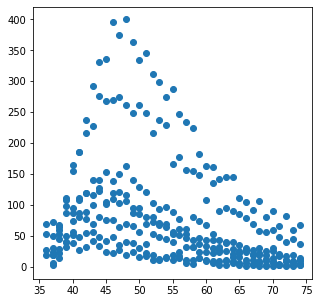

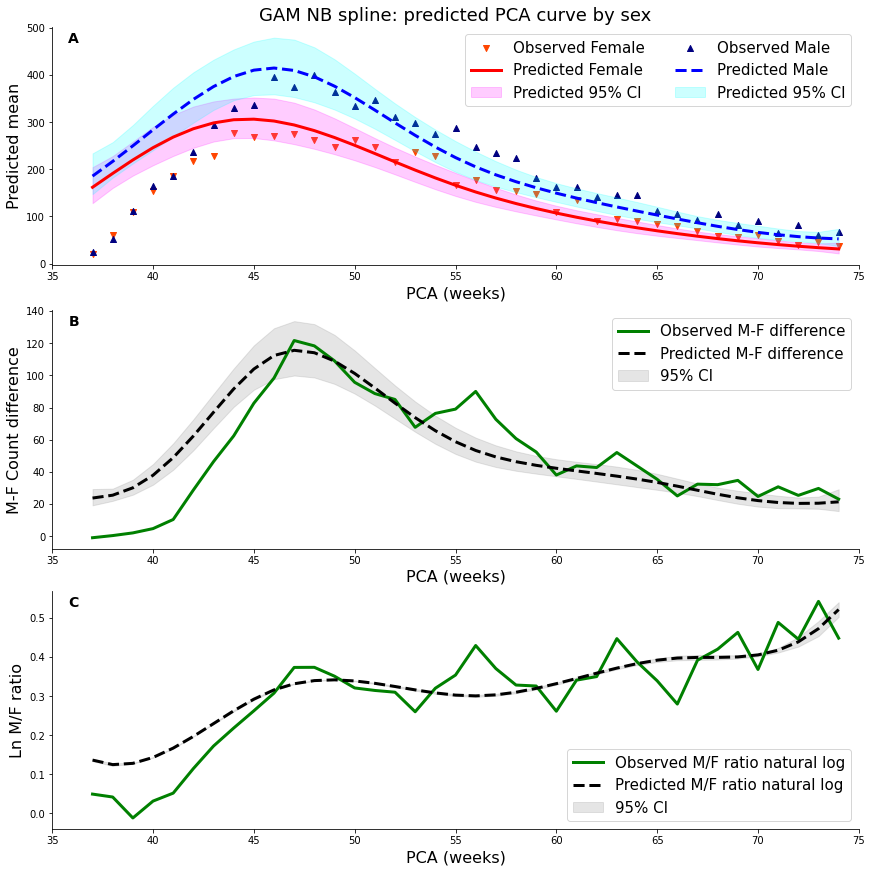

In [12]:
def main(var1,gestage,peak1,peak2,ages0,ages1,offset):
    # #### prologue: 
    binomial=0
    # fig, axs = plt.subplots(1,2, figsize=(16, 5), constrained_layout=True)

    # den_i, ii = death_rates('infage',0,axs[0])
    # den_p, ii = death_rates('pca', ii,axs[1])

    # #  Add panel labels
    # for ax, label in zip(axs, ["A", "B"]):
    #     ax.text(
    #         0.02, 0.98, label,
    #         transform=ax.transAxes,
    #         fontsize=18, fontweight="bold",
    #         va="top", ha="left"
    # )

    # # Save as TIFF at 300 dpi
    # fig.savefig("output_figures/pediatrics/Figure2.tiff", dpi=300, format="tiff")
    # fig.savefig("output_figures/pediatrics/Figure2.png")

    # # # # binomial regression
    case_df = load_case_control(var1,gestage)
    # binomial = run_binomial_pipeline(case_df,var1,gestage,peak1,peak2,ages0,ages1,offset)

    # ### risk ratio analysis:
    # rr = risk_ratio(case_df, den_i)
    # print('\nRR\n')
    # print(rr)

    ### NB GAM with Splines:
    NB_splines(var1,case_df)

    #### NCFRP
    # df = load_ncfrp_cases('inf3gestage')
    # trends, _ = visualize_ncfrp(df,var1,80)
    # # print(trends)
    # ncfrp = ncfrp_pipeline(df,trends,var1,ages0)
    return binomial
    # return ncfrp

if __name__=='__main__':
    # main('infage','combgest',7.5,np.array([1,8]), np.array([8,30]),np.array([1,8]))
    # binomial, ncfrp = main('pca','combgest',42.5,48, np.array([35,44]), np.array([44,80]),np.array([35,44]))
    
    peak1 = 43
    peak2 = 47
    # peak2 = 48

    # peak1 = 43
    # peak2 = 48

    binomial = main('pca','combgest',peak1,peak2, np.array([35,44]), np.array([44,80]),np.array([35,44]))